## Finetuning RelayBP for Qudit

In [ ]:
from bbq.field import Field
from bbq.polynomial import Monomial
from bbq.bbq_code import BivariateBicycle
from bbq.decoder import RelayBP, BPOSD, BP
from bbq.simulation import process_results

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from relay_bp import RelayDecoderF32


## Threshold plots

In [2]:
d = 3
field = Field(2)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals

p = 0.03
num_trials = 3000

bp_max_iter = 300

max_iter = 60
first_iter = 80
solutions = 1
relays = 10


In [ ]:
physical_error = np.logspace(-0.7, -1.8, 10)
num_failures = [20 for _ in range(10)]
physical_error


array([0.19952623, 0.15058364, 0.11364637, 0.08576959, 0.06473082,
       0.04885274, 0.03686945, 0.02782559, 0.02100014, 0.01584893])

In [ ]:
c = 0.05
w = 0.2


In [ ]:
print(f'Simulation for error rates {physical_error}')

results_rust = []
results_relaybp = []
results_bposd = []
results_bp = []

for ind, p in enumerate(physical_error):
    print(f'Starting trials for p={p:.2f}')

    n_qudits = hx.shape[1]
    channel_prob_x = np.ones(n_qudits) * p
    x_prior = np.zeros((n_qudits, field.p), dtype=float)

    for i, prob in enumerate(channel_prob_x):
        x_prior[i, 0] = 1 - prob
        for j in range(1, field.p):
            x_prior[i, j] = prob / (field.p - 1)

    failures_rust = 0
    failures_relaybp = 0
    failures_bposd = 0
    failures_bp = 0
    failures = sum([failures_rust, failures_relaybp, failures_bposd, failures_bp])

    trials = 0

    while failures < 4 * num_failures[ind]:
        trials += 1

        mem_weight = np.zeros((n_qudits, field.p, relays))
        mem_weight[:, :, 0] = c
        mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, field.p, relays - 1))

        # Generate syndrome
        error = np.zeros(n_qudits, dtype=int)
        error_mask = np.random.rand(n_qudits) < p
        for i in np.where(error_mask)[0]:
            error[i] = np.random.randint(1, field.p)
        syndrome = (hx @ error) % field.p

        # Decode
        if failures_bp < num_failures[ind]:
            bp = BP(field, hx, x_prior, bp_max_iter)
            guessed_error, decoder_success, bp_success, posterior = bp.decode(syndrome, debug=True, metric=False)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_bp += 1

            if failures_bp == num_failures[ind]:
                results_bp.append(trials)
                print(f'Completed BP: {trials}')

        if failures_bposd < num_failures[ind]:
            bposd = BPOSD(field, hx, x_prior, bp_max_iter)
            guessed_error, decoder_success, bp_success, posterior = bposd.decode(syndrome, debug=True, metric=False)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_bposd += 1

            if failures_bposd == num_failures[ind]:
                results_bposd.append(trials)
                print(f'Completed BPOSD: {trials}')

        if failures_relaybp < num_failures[ind]:
            relaybp = RelayBP(field, hx, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
            guessed_error, decoder_success, bp_success, posterior = relaybp.decode(syndrome, debug=True, metric=False)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_relaybp += 1

            if failures_relaybp == num_failures[ind]:
                results_relaybp.append(trials)
                print(f'Completed RelayBP: {trials}')

        if failures_rust < num_failures[ind]:
            rustrelaybp = RelayDecoderF32(hx, error_priors=channel_prob_x, gamma0=c, pre_iter=first_iter, num_sets=relays, set_max_iter=max_iter, gamma_dist_interval=(c - w/2, c + w/2), stop_nconv=1)
            syndrome = syndrome.astype(np.uint8)
            guessed_error = rustrelaybp.decode(syndrome)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_rust += 1

            if failures_rust == num_failures[ind]:
                results_rust.append(trials)
                print(f'Completed RustRelayBP: {trials}')

            if trials % 100 == 0:
                print(f'UPDATE: {trials} trials reached.')

        failures = sum([failures_rust, failures_relaybp, failures_bposd, failures_bp])
    print(f'[{ind+1}/{len(physical_error)}]')


Simulation for error rates [0.19952623 0.15058364 0.11364637 0.08576959 0.06473082 0.04885274
 0.03686945 0.02782559 0.02100014 0.01584893]
Starting trials for p=0.20
Completed BPOSD: 26
Completed RustRelayBP: 26
Completed RelayBP: 30
Completed BP: 31
[1/10]
Starting trials for p=0.15
Completed BPOSD: 29
Completed RelayBP: 33
Completed BP: 34
Completed RustRelayBP: 34
[2/10]
Starting trials for p=0.11
Completed BP: 47
Completed RelayBP: 51
Completed RustRelayBP: 62
Completed BPOSD: 63
[3/10]
Starting trials for p=0.09
Completed BP: 68
Completed RelayBP: 86
Completed RustRelayBP: 87
Completed BPOSD: 111
[4/10]
Starting trials for p=0.06
UPDATE: 100 trials reached.
Completed BP: 169
UPDATE: 200 trials reached.
UPDATE: 300 trials reached.
Completed BPOSD: 356
Completed RustRelayBP: 356
Completed RelayBP: 420
[5/10]
Starting trials for p=0.05
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.
Completed BP: 231
UPDATE: 300 trials reached.
UPDATE: 400 trials reached.
UPDATE: 500 trials 

In [ ]:
print(results_rust, results_relaybp, results_bposd, results_bp)


[26, 34, 62, 87, 356, 692, 1734, 4387, 10170, 22875] [30, 33, 51, 86, 420, 692, 1662, 4387, 10170, 22875] [26, 29, 63, 111, 356, 734, 1734, 4291, 13456, 22875] [31, 34, 47, 68, 169, 231, 413, 658, 1009, 2411]


In [ ]:
results_5 = {1:[26, 34, 62, 87, 356, 692, 1734, 4387, 10170, 22875],
             2:[30, 33, 51, 86, 420, 692, 1662, 4387, 10170, 22875],
             3:[26, 29, 63, 111, 356, 734, 1734, 4291, 13456, 22875],
             4:[31, 34, 47, 68, 169, 231, 413, 658, 1009, 2411]}


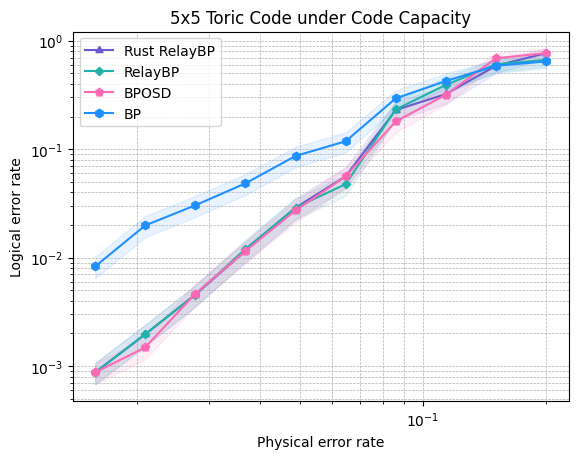

In [31]:
legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='Rust RelayBP'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='RelayBP'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='BPOSD'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='BP')
]

physical_error = np.logspace(-0.7, -1.8, 10)
plot_results, plot_errors = process_results(results_5, {1:20, 2:20, 3:20, 4:20}, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_results[1], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error, plot_results[2], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error, plot_results[3], color='hotpink', marker=(5, 0, 0))
ax.loglog(physical_error, plot_results[4], color='dodgerblue', marker=(6, 0, 0))
ax.fill_between(physical_error, plot_results[1] - plot_errors[1], plot_results[1] + plot_errors[1], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_results[2] - plot_errors[2], plot_results[2] + plot_errors[2], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_results[3] - plot_errors[3], plot_results[3] + plot_errors[3], color='hotpink', alpha=alpha)
ax.fill_between(physical_error, plot_results[4] - plot_errors[4], plot_results[4] + plot_errors[4], color='dodgerblue', alpha=alpha)

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('5x5 Toric Code under Code Capacity');


In [ ]:
results_3 = {1:[26, 52, 60, 66, 160, 255, 729, 936, 2661, 3594],
           2:[29, 49, 53, 66, 160, 346, 714, 945, 2684, 3594],
           3:[26, 55, 53, 63, 160, 351, 729, 945, 2192, 3819],
           4:[27, 40, 51, 63, 93, 177, 407, 587, 1245, 1658]}


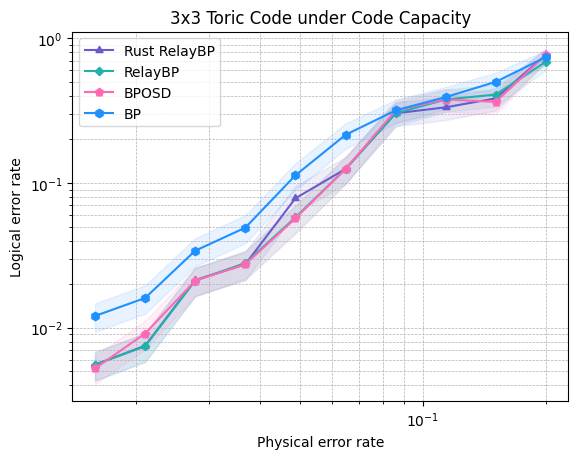

In [28]:
legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='Rust RelayBP'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='RelayBP'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='BPOSD'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='BP')
]

physical_error = np.logspace(-0.7, -1.8, 10)
plot_results, plot_errors = process_results(results_3, {1:20, 2:20, 3:20, 4:20}, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_results[1], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error, plot_results[2], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error, plot_results[3], color='hotpink', marker=(5, 0, 0))
ax.loglog(physical_error, plot_results[4], color='dodgerblue', marker=(6, 0, 0))
ax.fill_between(physical_error, plot_results[1] - plot_errors[1], plot_results[1] + plot_errors[1], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_results[2] - plot_errors[2], plot_results[2] + plot_errors[2], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_results[3] - plot_errors[3], plot_results[3] + plot_errors[3], color='hotpink', alpha=alpha)
ax.fill_between(physical_error, plot_results[4] - plot_errors[4], plot_results[4] + plot_errors[4], color='dodgerblue', alpha=alpha)

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('3x3 Toric Code under Code Capacity');


In [ ]:
tor_res = {}
tor_res[3] = [149, 179, 249, 312, 411, 839, 1016, 1728, 2823, 4575]
tor_res[5] = [158, 165, 244, 400, 800, 1354, 3520, 5577, 15918, 42051]
tor_res[7] = [125, 150, 220, 381, 823, 1654, 4841, 14311, 44000, 130165]
tor_res[9] = [144, 165, 188, 310, 595, 1728, 7021, 21232, 61251, 232855]
tor_res[11] = [134, 162, 167, 279, 673, 1514, 4295, 15566, 65778, 215716]


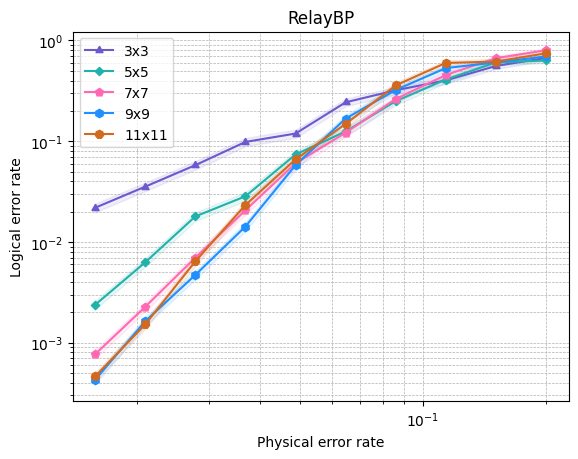

In [146]:
legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='3x3'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='5x5'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='7x7'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='9x9'),
    Line2D([0], [0], color='chocolate', marker=(7, 0, 0), linestyle='-', label='11x11')
]

physical_error = np.logspace(-0.7, -1.8, 10)
plot_results, plot_errors = process_results(tor_res, {3:100, 5:100, 7:100, 9:100, 11:100}, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_results[3], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error, plot_results[5], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error, plot_results[7], color='hotpink', marker=(5, 0, 0))
ax.loglog(physical_error, plot_results[9], color='dodgerblue', marker=(6, 0, 0))
ax.loglog(physical_error, plot_results[11], color='chocolate', marker=(7, 0, 0))
ax.fill_between(physical_error, plot_results[3] - plot_errors[3], plot_results[3] + plot_errors[3], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_results[5] - plot_errors[5], plot_results[5] + plot_errors[5], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_results[7] - plot_errors[7], plot_results[7] + plot_errors[7], color='hotpink', alpha=alpha)
ax.fill_between(physical_error, plot_results[9] - plot_errors[9], plot_results[9] + plot_errors[9], color='dodgerblue', alpha=alpha)
ax.fill_between(physical_error, plot_results[11] - plot_errors[11], plot_results[11] + plot_errors[11], color='chocolate', alpha=alpha)

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('RelayBP');


In [ ]:
physical_error


array([0.19952623, 0.15058364, 0.11364637, 0.08576959, 0.06473082,
       0.04885274, 0.03686945, 0.02782559, 0.02100014, 0.01584893])

## Centre-width search

In [ ]:
d = 7
field = Field(3)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals

p = 0.03
num_trials = 1000

# x_order = ['idle', 0, 3, 1, 2]
# z_order = [0, 3, 1, 2, 'idle']
# num_cycles = d

max_iter = 60
first_iter = 80
solutions = 1
relays = 10
# centre = 0.125
# width = 0.9
# centre = np.arange(0.0, 1.05, 0.05)
# width = np.arange(0.1, 2.1, 0.1)
# centre = np.linspace(-2.0, 2.0, 21)
# width = np.linspace(0.0, 4.0, 20)
# centre = np.linspace(-2.0, 2.0, 21)
# width = np.linspace(0.4, 0.6, 20)
# centre = np.linspace(0.6, 0.605, 21)
# width = np.linspace(0.0, 4.0, 20)

# centre = np.linspace(0.0, 1, 41)
# width = np.linspace(0.0, 2, 41)[1:]
# centre = np.linspace(0.0, 1, 21)
# width = np.linspace(0.0, 2, 21)[1:]
# centre = np.linspace(0.0, 5, 31)
# width = np.linspace(0.0, 10, 31)[1:]
centre = np.linspace(0.0, 1, 51)
width = np.linspace(0.0, 2, 51)[0:1]
# centre = np.linspace(0.0, 1, 101)
# width = np.linspace(0.0, 2, 101)[1:]

# circ = construct_sm_circuit(bb, x_order, z_order)


In [65]:
print(f'Setting up error channel for p = {p}...')
n_qudits = hx.shape[1]
channel_prob_x = np.ones(n_qudits) * p
x_prior = np.zeros((n_qudits, field.p), dtype=float)

for i, prob in enumerate(channel_prob_x):
    x_prior[i, 0] = 1 - prob
    for j in range(1, field.p):
        x_prior[i, j] = prob / (field.p - 1)

print('Starting trials...')
results = np.zeros((len(centre), len(width)))

for ci, c in enumerate(centre):
    for wi, w in enumerate(width):
        mem_weight = np.zeros((n_qudits, field.p, relays))
        mem_weight[:, :, 0] = c
        mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, field.p, relays - 1))

        # mem_weight = np.zeros((n_qudits, field.p, relays))
        # mem_weight[:, :, 0] = c
        # rand = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, relays - 1))
        # for i in range(0, field.p):
        #     mem_weight[:, i, 1:] = rand

        failures = 0

        for t in range(num_trials):

            # Set up decoder
            relaybp = RelayBP(field, hx, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
            # relaybp = RelayDecoderF32(hx, error_priors=channel_prob_x, gamma0=c, pre_iter=first_iter, num_sets=relays, set_max_iter=max_iter, gamma_dist_interval=(c - w/2, c + w/2), stop_nconv=1)

            # Generate syndrome
            error = np.zeros(n_qudits, dtype=int)
            error_mask = np.random.rand(n_qudits) < p
            for i in np.where(error_mask)[0]:
                error[i] = np.random.randint(1, field.p)
            syndrome = (hx @ error) % field.p

            # Decode
            guessed_error, decoder_success, bp_success, posterior = relaybp.decode(syndrome, metric=False, debug=True)
            # syndrome = syndrome.astype(np.uint8)
            # guessed_error = relaybp.decode(syndrome)
            error_difference = (error - guessed_error) % field.p

            logical_effect = (np.array(lx) @ error_difference) % field.p

            # Check success
            if np.any(logical_effect != 0):
                failures += 1

        results[ci, wi] = failures
        print(f'Finished {ci+1}/{len(centre)} centres and {wi+1}/{len(width)} widths.')
    # print(f'Finished {ci+1}/{len(centre)} centres and {wi+1}/{len(width)} widths.')

print('Completed simulation')


Setting up error channel for p = 0.03...
Starting trials...
Finished 1/51 centres and 1/1 widths.
Finished 2/51 centres and 1/1 widths.
Finished 3/51 centres and 1/1 widths.
Finished 4/51 centres and 1/1 widths.
Finished 5/51 centres and 1/1 widths.
Finished 6/51 centres and 1/1 widths.
Finished 7/51 centres and 1/1 widths.
Finished 8/51 centres and 1/1 widths.
Finished 9/51 centres and 1/1 widths.
Finished 10/51 centres and 1/1 widths.
Finished 11/51 centres and 1/1 widths.
Finished 12/51 centres and 1/1 widths.
Finished 13/51 centres and 1/1 widths.
Finished 14/51 centres and 1/1 widths.
Finished 15/51 centres and 1/1 widths.
Finished 16/51 centres and 1/1 widths.
Finished 17/51 centres and 1/1 widths.
Finished 18/51 centres and 1/1 widths.
Finished 19/51 centres and 1/1 widths.
Finished 20/51 centres and 1/1 widths.
Finished 21/51 centres and 1/1 widths.
Finished 22/51 centres and 1/1 widths.
Finished 23/51 centres and 1/1 widths.
Finished 24/51 centres and 1/1 widths.
Finished 25/5

/Users/eleanorkneip/Documents/phd/bbq-project/bbqudit/bbq/decoder.py:516: RuntimeWarning: invalid value encountered in divide
  sub_posteriors / np.sum(sub_posteriors, axis=1)[:, np.newaxis]
/Users/eleanorkneip/Documents/phd/bbq-project/bbqudit/bbq/decoder.py:219: RuntimeWarning: invalid value encountered in divide
  sub_convolutions = sub_convolutions / convolution
/Users/eleanorkneip/Documents/phd/bbq-project/bbqudit/bbq/decoder.py:537: RuntimeWarning: invalid value encountered in divide
  posteriors /= np.sum(posteriors, axis=1)[:, np.newaxis]


Finished 51/51 centres and 1/1 widths.
Completed simulation


In [ ]:
results


array([[16.],
       [ 0.],
       [ 0.],
       [ 0.],
       [ 1.],
       [ 0.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 0.],
       [ 0.],
       [ 0.],
       [ 0.],
       [ 0.],
       [ 0.],
       [ 0.],
       [ 0.],
       [ 1.],
       [ 0.],
       [ 1.],
       [ 0.],
       [ 2.],
       [ 0.],
       [ 1.],
       [ 0.],
       [ 1.],
       [ 2.],
       [ 1.],
       [ 1.],
       [ 0.],
       [ 1.],
       [ 1.],
       [ 0.],
       [ 0.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 2.],
       [11.],
       [14.],
       [ 8.],
       [ 8.],
       [ 3.],
       [ 1.],
       [ 7.],
       [14.],
       [ 4.],
       [15.],
       [30.]])

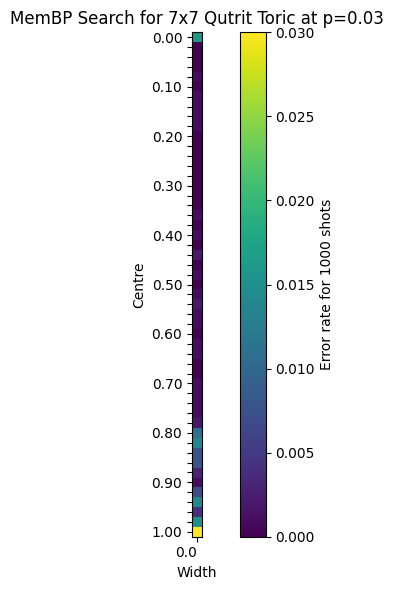

In [ ]:
centre = np.linspace(0.0, 1, 51)
width = np.linspace(0.0, 2, 51)[0:1]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 1000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' if ci % 5 == 0 else ' ' for ci, c in enumerate(centre)])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 1000 shots")

ax.set_title("MemBP Search for 7x7 Qutrit Toric at p=0.03")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[31.],
       [ 9.],
       [ 7.],
       [ 9.],
       [ 8.],
       [ 4.],
       [ 3.],
       [ 5.],
       [ 6.],
       [ 6.],
       [ 6.],
       [ 6.],
       [ 3.],
       [ 2.],
       [ 3.],
       [ 9.],
       [ 3.],
       [ 5.],
       [13.],
       [ 8.],
       [ 6.],
       [ 5.],
       [ 9.],
       [ 8.],
       [ 6.],
       [ 5.],
       [ 6.],
       [ 4.],
       [ 9.],
       [ 6.],
       [ 5.],
       [ 4.],
       [ 2.],
       [ 8.],
       [ 4.],
       [ 8.],
       [ 7.],
       [ 7.],
       [14.],
       [20.],
       [21.],
       [19.],
       [20.],
       [19.],
       [18.],
       [20.],
       [41.],
       [23.],
       [57.],
       [32.],
       [44.]])

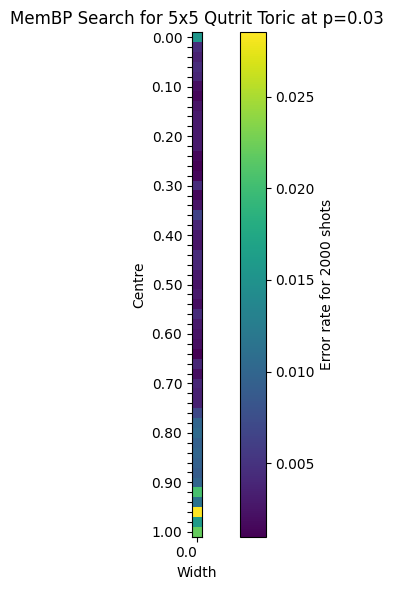

In [ ]:
centre = np.linspace(0.0, 1, 51)
width = np.linspace(0.0, 2, 51)[0:1]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 2000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' if ci % 5 == 0 else ' ' for ci, c in enumerate(centre)])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 2000 shots")

ax.set_title("MemBP Search for 5x5 Qutrit Toric at p=0.03")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[123.],
       [ 72.],
       [ 66.],
       [ 70.],
       [ 68.],
       [ 76.],
       [ 99.],
       [ 69.],
       [101.],
       [ 93.],
       [ 83.],
       [ 73.],
       [ 93.],
       [ 89.],
       [ 76.],
       [ 86.],
       [ 85.],
       [ 85.],
       [ 67.],
       [ 97.],
       [ 72.],
       [ 81.],
       [ 70.],
       [ 70.],
       [ 82.],
       [125.],
       [118.],
       [106.],
       [123.],
       [110.],
       [114.],
       [127.],
       [114.],
       [127.],
       [127.],
       [123.],
       [110.],
       [140.],
       [112.],
       [114.],
       [116.],
       [125.],
       [112.],
       [128.],
       [116.],
       [122.],
       [132.],
       [144.],
       [157.],
       [154.],
       [108.]])

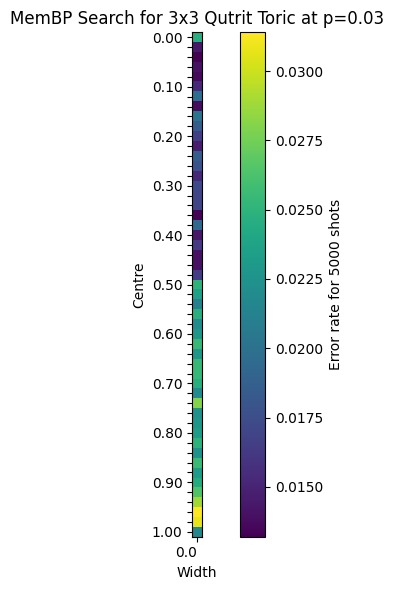

In [ ]:
centre = np.linspace(0.0, 1, 51)
width = np.linspace(0.0, 2, 51)[0:1]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 5000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' if ci % 5 == 0 else ' ' for ci, c in enumerate(centre)])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 5000 shots")

ax.set_title("MemBP Search for 3x3 Qutrit Toric at p=0.03")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[49.],
       [11.],
       [ 4.],
       [ 5.],
       [ 5.],
       [ 5.],
       [ 3.],
       [ 4.],
       [ 5.],
       [ 4.],
       [ 6.],
       [ 2.],
       [ 0.],
       [ 4.],
       [10.],
       [ 2.],
       [ 4.],
       [ 5.],
       [ 3.],
       [ 2.],
       [ 2.],
       [ 2.],
       [ 5.],
       [ 5.],
       [ 1.],
       [ 3.],
       [ 5.],
       [ 2.],
       [ 5.],
       [ 4.],
       [ 7.],
       [ 9.],
       [ 8.],
       [ 8.],
       [10.],
       [ 2.],
       [ 6.],
       [ 4.],
       [12.],
       [ 6.],
       [10.],
       [10.],
       [10.],
       [ 8.],
       [ 5.],
       [ 5.],
       [ 8.],
       [ 9.],
       [25.],
       [20.],
       [72.]])

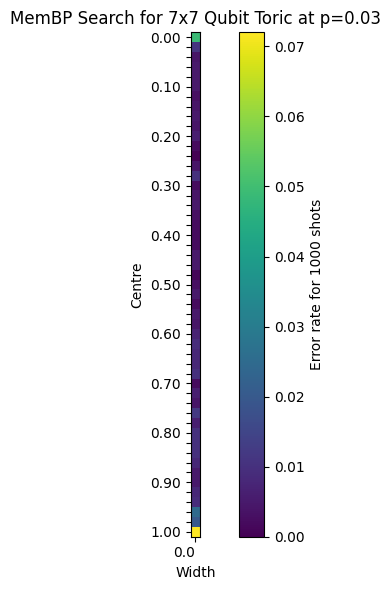

In [ ]:
centre = np.linspace(0.0, 1, 51)
width = np.linspace(0.0, 2, 51)[0:1]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 1000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' if ci % 5 == 0 else ' ' for ci, c in enumerate(centre)])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 1000 shots")

ax.set_title("MemBP Search for 7x7 Qubit Toric at p=0.03")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[68.],
       [14.],
       [20.],
       [23.],
       [13.],
       [ 9.],
       [20.],
       [14.],
       [10.],
       [11.],
       [ 8.],
       [ 8.],
       [ 9.],
       [20.],
       [20.],
       [15.],
       [ 8.],
       [15.],
       [14.],
       [11.],
       [14.],
       [17.],
       [10.],
       [22.],
       [18.],
       [24.],
       [21.],
       [13.],
       [34.],
       [32.],
       [30.],
       [38.],
       [24.],
       [28.],
       [37.],
       [38.],
       [29.],
       [32.],
       [35.],
       [28.],
       [27.],
       [40.],
       [30.],
       [34.],
       [35.],
       [30.],
       [50.],
       [40.],
       [41.],
       [44.],
       [90.]])

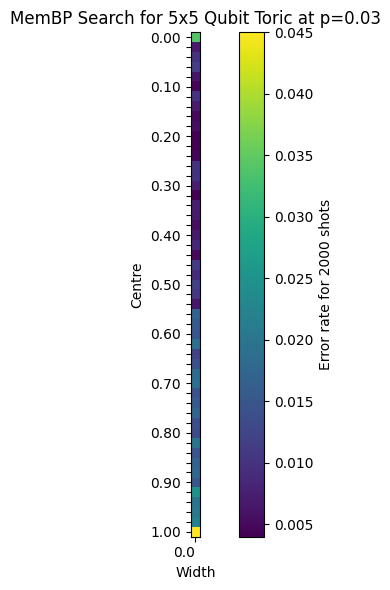

In [ ]:
centre = np.linspace(0.0, 1, 51)
width = np.linspace(0.0, 2, 51)[0:1]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 2000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' if ci % 5 == 0 else ' ' for ci, c in enumerate(centre)])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 2000 shots")

ax.set_title("MemBP Search for 5x5 Qubit Toric at p=0.03")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[183.],
       [123.],
       [116.],
       [108.],
       [126.],
       [118.],
       [100.],
       [123.],
       [114.],
       [102.],
       [121.],
       [119.],
       [117.],
       [121.],
       [116.],
       [117.],
       [132.],
       [108.],
       [120.],
       [112.],
       [133.],
       [178.],
       [160.],
       [180.],
       [174.],
       [110.],
       [153.],
       [126.],
       [108.],
       [125.],
       [121.],
       [315.],
       [309.],
       [302.],
       [284.],
       [308.],
       [310.],
       [253.],
       [249.],
       [279.],
       [313.],
       [247.],
       [208.],
       [314.],
       [216.],
       [249.],
       [265.],
       [322.],
       [243.],
       [267.],
       [253.]])

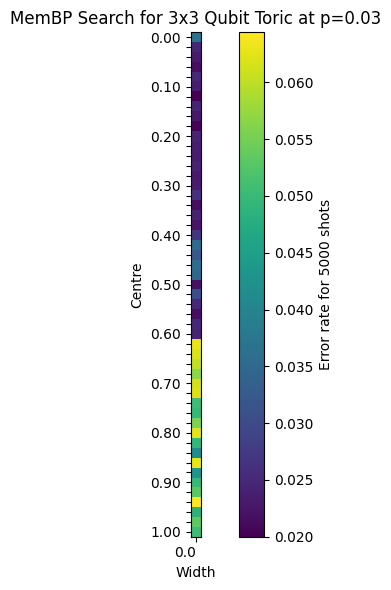

In [ ]:
centre = np.linspace(0.0, 1, 51)
width = np.linspace(0.0, 2, 51)[0:1]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 5000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' if ci % 5 == 0 else ' ' for ci, c in enumerate(centre)])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 5000 shots")

ax.set_title("MemBP Search for 3x3 Qubit Toric at p=0.03")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[ 22.,  13.,  18.,  34.,  51.,  76.,  84.,  91.,  95.,  98.,  95.,
         99., 101.,  94.,  76.,  92.,  67.,  88.,  84.,  89.,  81.,  70.,
         79.,  83.,  92.,  75.,  86.,  92.,  85.,  91.],
       [ 12.,  18.,  19.,  20.,  27.,  39.,  50.,  57.,  59.,  50.,  64.,
         51.,  60.,  59.,  57.,  50.,  61.,  47.,  51.,  55.,  57.,  52.,
         56.,  51.,  51.,  65.,  46.,  62.,  55.,  56.],
       [ 28.,  16.,  32.,  38.,  42.,  69.,  70.,  61.,  60.,  63.,  50.,
         69.,  61.,  58.,  62.,  61.,  61.,  58.,  52.,  49.,  54.,  50.,
         51.,  65.,  65.,  56.,  47.,  57.,  40.,  57.],
       [ 23.,  33.,  27.,  80.,  98., 123.,  68.,  55.,  51.,  66.,  79.,
         63.,  66.,  69.,  66.,  63.,  57.,  65.,  66.,  55.,  52.,  68.,
         46.,  65.,  62.,  60.,  59.,  65.,  72.,  73.],
       [ 38.,  42.,  44.,  45.,  63., 105.,  91.,  61.,  68.,  76.,  68.,
         78.,  71.,  81.,  69.,  65.,  63.,  61.,  72.,  83.,  73.,  64.,
         54.,  71.,  56.,  61., 

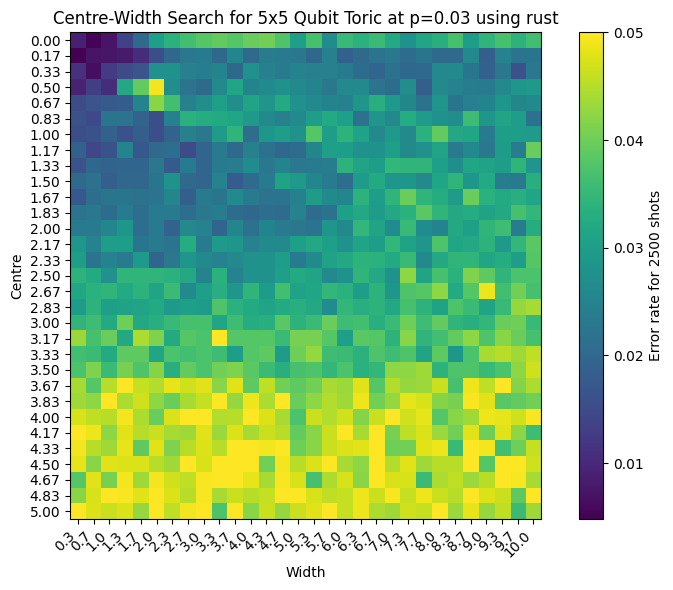

In [ ]:
centre = np.linspace(0.0, 5, 31)
width = np.linspace(0.0, 10, 31)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 2500, vmax=0.05)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 2500 shots")

ax.set_title("Centre-Width Search for 5x5 Qubit Toric at p=0.03 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[511., 511., 514., 485., 508., 519., 517., 495., 502., 526., 528.,
        530., 521., 561., 492., 544., 518., 534., 513., 544., 520., 502.,
        483., 544., 504., 506., 535., 534., 482., 531.],
       [505., 551., 511., 494., 522., 551., 507., 488., 550., 538., 533.,
        502., 526., 494., 544., 518., 506., 527., 525., 487., 517., 524.,
        511., 513., 524., 532., 535., 555., 559., 499.],
       [582., 528., 559., 503., 509., 551., 517., 520., 519., 500., 529.,
        519., 522., 534., 510., 542., 495., 531., 518., 531., 523., 536.,
        510., 547., 521., 533., 513., 515., 532., 491.],
       [512., 545., 531., 526., 542., 528., 546., 535., 536., 522., 550.,
        521., 542., 521., 567., 516., 525., 520., 523., 540., 543., 542.,
        567., 525., 508., 546., 537., 551., 546., 555.],
       [523., 542., 519., 524., 535., 533., 519., 528., 548., 551., 547.,
        542., 533., 513., 545., 527., 510., 550., 530., 546., 557., 521.,
        566., 528., 564., 532., 

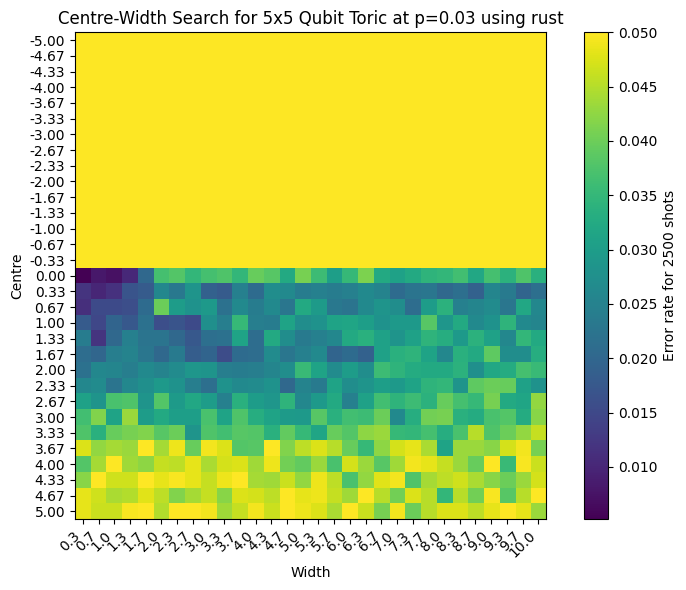

In [ ]:
centre = np.linspace(-5, 5, 31)
width = np.linspace(0.0, 10, 31)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 2500, vmax=0.05)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 2500 shots")

ax.set_title("Centre-Width Search for 5x5 Qubit Toric at p=0.03 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[1984., 1986., 1943., 1968., 1938., 1922., 1999., 1988., 1981.,
        1972., 1994., 1977., 1992., 2061., 2035., 2055., 2068., 2052.,
        2087., 2068.],
       [1975., 2010., 1984., 1978., 1996., 2021., 1922., 1937., 2019.,
        1999., 2002., 2030., 1965., 1979., 2061., 1983., 2001., 1993.,
        2003., 2023.],
       [1987., 2003., 1967., 1929., 2000., 1967., 1983., 1982., 2009.,
        1945., 2033., 1942., 1969., 1997., 2008., 1997., 2026., 2034.,
        1997., 2050.],
       [1970., 1955., 1985., 1980., 1932., 1909., 1950., 1913., 1975.,
        1946., 2011., 2001., 1969., 2003., 1979., 1940., 1986., 1973.,
        1994., 1982.],
       [1934., 1943., 1944., 2026., 1912., 2006., 1915., 2006., 1981.,
        1939., 1991., 1974., 1973., 1973., 1967., 1990., 1950., 1985.,
        1939., 1992.],
       [1963., 1946., 1951., 1982., 2043., 1972., 1984., 1952., 1984.,
        1965., 1946., 1937., 1975., 1984., 1962., 1966., 1964., 1953.,
        2000., 2015.],
       [19

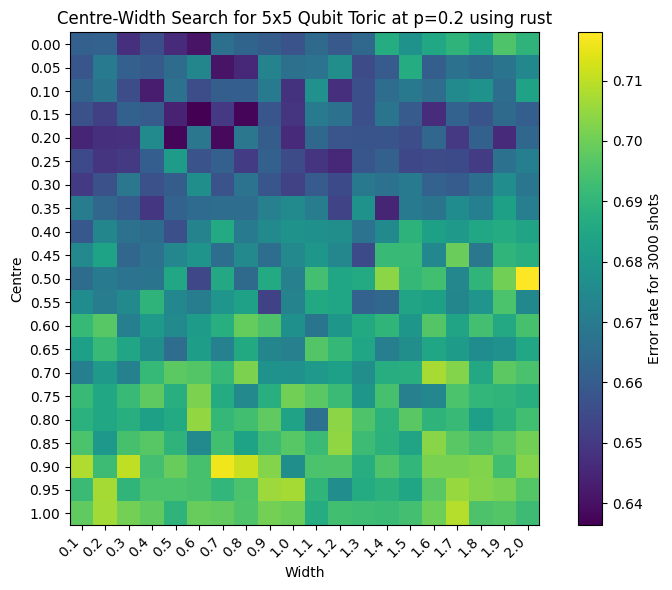

In [ ]:
centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 3000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 3000 shots")

ax.set_title("Centre-Width Search for 5x5 Qubit Toric at p=0.2 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


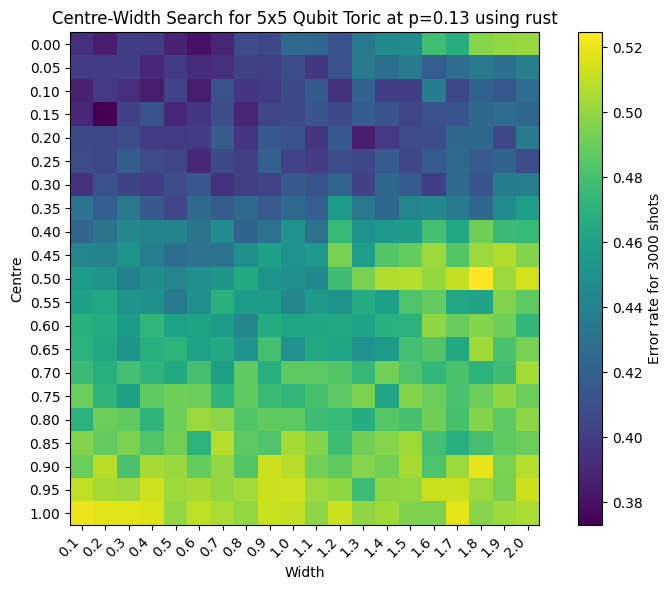

In [ ]:
results = np.array([[1180., 1158., 1204., 1200., 1164., 1141., 1167., 1223., 1218., 1275., 1273., 1233., 1303., 1337., 1341., 1435., 1402., 1491., 1501., 1504.],
       [1200., 1199., 1203., 1170., 1196., 1177., 1180., 1207., 1206., 1226., 1192., 1231., 1308., 1283., 1307., 1255., 1282., 1307., 1286., 1318.],
       [1160., 1194., 1181., 1154., 1211., 1155., 1231., 1191., 1200., 1222., 1247., 1186., 1262., 1203., 1203., 1312., 1216., 1261., 1245., 1282.],
       [1169., 1119., 1207., 1238., 1170., 1193., 1226., 1167., 1214., 1219., 1241., 1217., 1251., 1237., 1214., 1232., 1238., 1273., 1281., 1272.],
       [1220., 1216., 1227., 1198., 1197., 1198., 1252., 1190., 1242., 1237., 1191., 1245., 1158., 1195., 1223., 1226., 1271., 1271., 1216., 1306.],
       [1224., 1215., 1253., 1224., 1214., 1170., 1221., 1206., 1258., 1210., 1199., 1227., 1217., 1252., 1216., 1251., 1275., 1249., 1266., 1226.],
       [1185., 1231., 1208., 1202., 1227., 1243., 1185., 1205., 1213., 1246., 1238., 1267., 1207., 1272., 1249., 1203., 1275., 1241., 1310., 1316.],
       [1292., 1255., 1301., 1246., 1215., 1277., 1251., 1276., 1249., 1275., 1255., 1370., 1302., 1271., 1326., 1333., 1309., 1273., 1339., 1374.],
       [1270., 1294., 1333., 1324., 1322., 1294., 1338., 1266., 1290., 1352., 1291., 1423., 1351., 1361., 1368., 1438., 1390., 1476., 1429., 1424.],
       [1328., 1323., 1355., 1315., 1284., 1293., 1292., 1348., 1379., 1352., 1361., 1481., 1372., 1452., 1467., 1506., 1452., 1505., 1520., 1489.],
       [1371., 1360., 1319., 1344., 1326., 1348., 1360., 1397., 1354., 1347., 1335., 1433., 1481., 1519., 1524., 1502., 1533., 1574., 1506., 1543.],
       [1379., 1394., 1354., 1348., 1306., 1348., 1408., 1368., 1369., 1330., 1363., 1352., 1399., 1376., 1448., 1465., 1391., 1385., 1487., 1462.],
       [1408., 1401., 1367., 1419., 1383., 1385., 1368., 1330., 1399., 1387., 1387., 1394., 1381., 1408., 1412., 1496., 1468., 1489., 1474., 1420.],
       [1411., 1393., 1358., 1405., 1413., 1381., 1394., 1356., 1438.,
        1349., 1396., 1387., 1349., 1369., 1437., 1452., 1396., 1509.,
        1444., 1480.],
       [1430., 1404., 1438., 1415., 1396., 1439., 1377., 1462., 1405.,
        1462., 1459., 1453., 1422., 1477., 1449., 1420., 1443., 1411.,
        1432., 1513.],
       [1470., 1416., 1378., 1461., 1474., 1471., 1417., 1463., 1430.,
        1420., 1441., 1460., 1484., 1387., 1489., 1471., 1444., 1471.,
        1498., 1472.],
       [1411., 1472., 1463., 1415., 1474., 1506., 1495., 1450., 1463.,
        1459., 1432., 1424., 1400., 1454., 1442., 1475., 1441., 1490.,
        1459., 1495.],
       [1487., 1465., 1484., 1451., 1479., 1414., 1524., 1460., 1448.,
        1513., 1489., 1432., 1475., 1491., 1509., 1438., 1405., 1440.,
        1463., 1470.],
       [1472., 1526., 1444., 1514., 1504., 1467., 1500., 1453., 1537.,
        1525., 1479., 1463., 1492., 1477., 1514., 1446., 1505., 1558.,
        1483., 1523.],
       [1530., 1512., 1507., 1542., 1508., 1515., 1501., 1511., 1537.,
        1541., 1505., 1496., 1431., 1498., 1500., 1537., 1538., 1505.,
        1481., 1540.],
       [1560., 1553., 1554., 1549., 1500., 1531., 1516., 1500., 1536.,
        1532., 1495., 1538., 1498., 1509., 1486., 1485., 1555., 1491.,
        1508., 1517.]])

centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 3000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 3000 shots")

ax.set_title("Centre-Width Search for 5x5 Qubit Toric at p=0.13 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


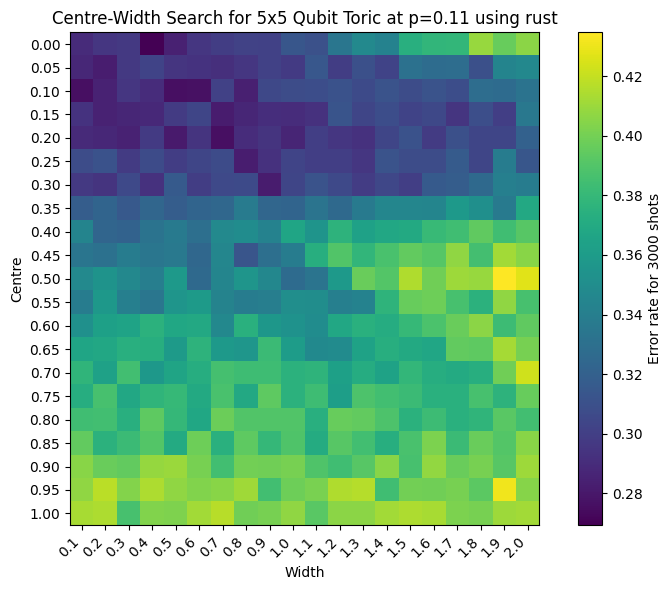

In [ ]:
results = np.array([[ 869.,  886.,  891.,  808.,  854.,  887.,  898.,  905.,  903.,  940.,  931., 1002., 1042., 1027., 1120., 1135., 1137., 1227., 1188., 1217.],
       [ 864.,  848.,  890.,  908.,  884.,  880.,  875.,  886.,  903., 892.,  943.,  898.,  929.,  907.,  993.,  984.,  985.,  930., 1032., 1040.],
       [ 829.,  856.,  887.,  870.,  828.,  830.,  904.,  852.,  916., 923.,  925.,  932.,  920.,  934.,  924.,  934.,  926.,  986., 981.,  996.],
       [ 881.,  856.,  862.,  866.,  894.,  911.,  846.,  862.,  873., 870.,  879.,  936.,  911.,  925.,  907.,  915.,  885.,  927., 900., 1006.],
       [ 868.,  864.,  856.,  892.,  843.,  883.,  829.,  871.,  883., 859.,  900.,  887.,  878.,  912.,  933.,  895.,  929.,  912., 912.,  962.],
       [ 923.,  932.,  894.,  921.,  899.,  911.,  922.,  847.,  879., 910.,  900.,  900.,  887.,  935.,  924.,  924.,  950.,  912.,1016.,  941.],
       [ 891.,  883.,  918.,  878.,  949.,  899.,  918.,  919.,  846., 912.,  935.,  917.,  896.,  914.,  900.,  949.,  955.,  977.,1023., 1016.],
       [ 955.,  968.,  946.,  971.,  954.,  968.,  974., 1014.,  971., 968.,  998.,  978., 1012., 1036., 1036., 1034., 1077., 1055.,1012., 1108.],
       [1031.,  970.,  963.,  996., 1011.,  990., 1042., 1049., 1027., 1099., 1064., 1128., 1092., 1106., 1109., 1142., 1151., 1182.,1152., 1175.],
       [1001.,  993., 1017., 1002., 1009.,  973., 1035.,  939.,  990., 1017., 1118., 1170., 1135., 1161., 1184., 1174., 1221., 1156.,1236., 1215.],
       [1041., 1063., 1040., 1020., 1077.,  977., 1033., 1066., 1038., 981.,  998., 1075., 1191., 1172., 1244., 1197., 1231., 1227.,1304., 1282.],
       [1017., 1073., 1023., 1003., 1067., 1078., 1029., 1016., 1020., 1054., 1052., 1022., 1027., 1130., 1188., 1195., 1159., 1127.,1222., 1160.],
       [1057., 1090., 1095., 1126., 1104., 1108., 1040., 1123., 1070., 1061., 1050., 1105., 1123., 1115., 1140., 1164., 1190., 1218., 1148., 1183.],
       [1100., 1106., 1120., 1118., 1079., 1128., 1076., 1069., 1146., 1082., 1044., 1047., 1093., 1119., 1109., 1102., 1184., 1181., 1238., 1202.],
       [1132., 1091., 1153., 1073., 1097., 1117., 1157., 1150., 1150., 1127., 1131., 1089., 1116., 1093., 1136., 1117., 1111., 1119., 1197., 1269.],
       [1117., 1160., 1106., 1132., 1141., 1109., 1162., 1107., 1180., 1126., 1150., 1086., 1166., 1154., 1147., 1123., 1122., 1159., 1129., 1189.],
       [1152., 1154., 1121., 1181., 1139., 1104., 1192., 1169., 1170., 1169., 1120., 1189., 1184., 1166., 1124., 1148., 1123., 1133., 1177., 1154.],
       [1185., 1126., 1147., 1171., 1111., 1195., 1123., 1181., 1138., 1167., 1113., 1176., 1154., 1118., 1162., 1206., 1146., 1190., 1171., 1216.],
       [1216., 1190., 1185., 1226., 1230., 1203., 1154., 1199., 1197., 1203., 1168., 1152., 1176., 1216., 1160., 1223., 1190., 1203., 1175., 1231.],
       [1221., 1252., 1211., 1243., 1222., 1210., 1216., 1234., 1153., 1194., 1205., 1245., 1249., 1152., 1199., 1196., 1202., 1179., 1293., 1214.],
       [1240., 1243., 1160., 1210., 1208., 1236., 1250., 1197., 1202., 1222., 1178., 1217., 1217., 1235., 1243., 1240., 1206., 1202., 1232., 1235.]])

centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 3000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 3000 shots")

ax.set_title("Centre-Width Search for 5x5 Qubit Toric at p=0.11 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


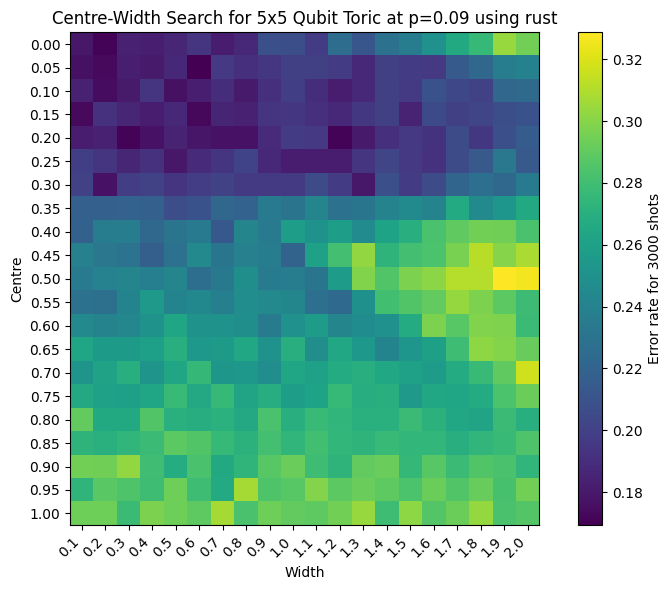

In [ ]:
results = np.array([[538., 512., 551., 549., 560., 579., 547., 563., 624., 623., 591.,
        678., 636., 689., 708., 749., 799., 828., 913., 884.],
       [530., 521., 548., 543., 562., 508., 587., 572., 584., 598., 598.,
        593., 561., 599., 592., 587., 644., 670., 709., 718.],
       [551., 523., 543., 582., 529., 549., 571., 543., 572., 596., 571.,
        547., 563., 598., 590., 628., 612., 603., 666., 674.],
       [520., 576., 560., 547., 563., 518., 558., 552., 580., 584., 574.,
        563., 585., 599., 556., 616., 599., 608., 622., 628.],
       [546., 552., 512., 531., 553., 537., 531., 531., 565., 593., 588.,
        513., 542., 574., 588., 578., 618., 586., 624., 647.],
       [597., 580., 559., 577., 538., 566., 580., 605., 561., 545., 544.,
        545., 579., 608., 587., 576., 617., 642., 700., 642.],
       [603., 532., 595., 603., 580., 595., 602., 590., 590., 589., 619.,
        592., 538., 624., 593., 618., 664., 682., 667., 704.],
       [655., 654., 659., 654., 621., 629., 665., 658., 703., 692., 725.,
        689., 694., 722., 734., 722., 801., 736., 760., 798.],
       [657., 709., 708., 669., 691., 705., 639., 725., 703., 776., 754.,
        776., 738., 786., 810., 848., 870., 885., 883., 849.],
       [716., 697., 690., 652., 687., 733., 693., 717., 709., 660., 782.,
        843., 908., 818., 843., 851., 889., 935., 900., 926.],
       [703., 720., 725., 715., 725., 680., 702., 746., 707., 708., 694.,
        771., 896., 857., 892., 902., 933., 933., 986., 978.],
       [686., 685., 723., 764., 723., 732., 714., 743., 733., 728., 683.,
        671., 748., 842., 857., 872., 910., 892., 866., 835.],
       [733., 722., 729., 751., 791., 754., 754., 746., 704., 749., 770.,
        726., 741., 749., 803., 891., 861., 896., 894., 834.],
       [789., 768., 769., 778., 810., 762., 769., 795., 753., 810., 745.,
        793., 762., 724., 759., 780., 837., 905., 897., 874.],
       [755., 784., 807., 755., 791., 827., 761., 763., 743., 790., 782.,
        803., 810., 794., 781., 772., 802., 830., 870., 951.],
       [797., 781., 778., 791., 832., 797., 829., 788., 805., 775., 785.,
        828., 806., 808., 766., 793., 790., 802., 851., 879.],
       [872., 799., 799., 856., 812., 806., 814., 796., 849., 810., 832.,
        823., 811., 812., 833., 815., 794., 788., 834., 810.],
       [819., 812., 823., 834., 865., 857., 829., 815., 844., 823., 842.,
        825., 818., 831., 825., 824., 809., 823., 832., 854.],
       [884., 883., 908., 839., 804., 849., 798., 820., 861., 876., 837.,
        818., 872., 877., 827., 862., 834., 857., 849., 823.],
       [821., 864., 854., 837., 881., 838., 801., 922., 855., 861., 897.,
        865., 877., 867., 850., 878., 857., 874., 846., 885.],
       [880., 881., 833., 891., 880., 867., 922., 849., 881., 872., 867.,
        884., 913., 838., 904., 859., 879., 911., 848., 858.]])

centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 3000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 3000 shots")

ax.set_title("Centre-Width Search for 5x5 Qubit Toric at p=0.09 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


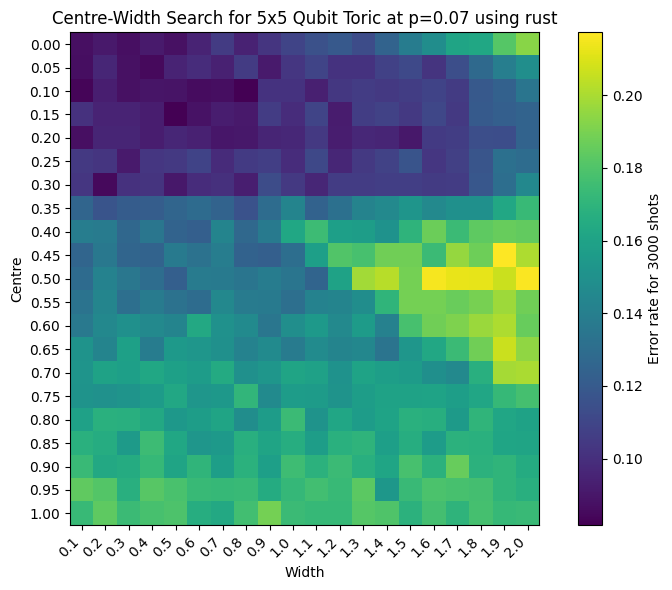

In [ ]:
results = np.array([[261., 273., 261., 275., 263., 286., 315., 284., 308., 329., 346., 358., 340., 374., 416., 444., 482., 488., 545., 579.],
       [260., 288., 264., 255., 285., 297., 282., 315., 274., 309., 329., 304., 304., 323., 335., 307., 343., 384., 419., 446.],
       [250., 279., 263., 268., 266., 259., 260., 246., 304., 305., 281., 311., 318., 313., 319., 327., 315., 359., 372., 403.],
       [303., 286., 285., 277., 245., 265., 277., 273., 317., 297., 328., 276., 319., 326., 312., 332., 313., 361., 368., 375.],
       [262., 287., 287., 277., 289., 283., 269., 272., 287., 290., 312., 278., 291., 287., 272., 314., 319., 342., 341., 374.],
       [313., 308., 275., 309., 312., 327., 295., 314., 320., 297., 333., 289., 312., 326., 350., 309., 322., 352., 395., 389.],
       [309., 256., 303., 307., 272., 296., 302., 279., 339., 312., 289., 318., 317., 320., 321., 316., 317., 356., 392., 435.],
       [378., 350., 364., 365., 378., 387., 374., 347., 389., 429., 373., 395., 427., 436., 457., 436., 450., 450., 489., 519.],
       [417., 415., 381., 404., 374., 368., 428., 382., 412., 488., 524., 475., 471., 453., 510., 561., 522., 551., 558., 555.],
       [377., 408., 377., 375., 411., 398., 417., 373., 369., 392., 475., 541., 534., 563., 563., 522., 587., 562., 652., 602.],
       [387., 425., 406., 391., 369., 414., 413., 403., 416., 403., 376., 480., 596., 608., 567., 647., 638., 637., 620., 649.],
       [400., 430., 393., 414., 399., 389., 435., 414., 411., 394., 425., 428., 445., 512., 567., 567., 559., 568., 593., 563.],
       [409., 435., 449., 436., 428., 490., 451., 440., 404., 446., 465., 437., 468., 424., 533., 563., 574., 590., 602., 558.],
       [454., 428., 476., 416., 465., 459., 450., 426., 440., 415., 442., 429., 434., 401., 459., 489., 523., 563., 619., 584.],
       [455., 480., 475., 488., 476., 470., 494., 450., 459., 482., 478., 453., 481., 473., 469., 448., 436., 502., 597., 600.],
       [454., 451., 456., 468., 489., 459., 462., 513., 440., 470., 468., 454., 472., 480., 479., 481., 473., 486., 517., 532.],
       [478., 503., 501., 491., 462., 471., 482., 444., 470., 523., 454., 486., 470., 481., 504., 500., 467., 512., 486., 479.],
       [503., 497., 466., 524., 487., 459., 465., 501., 482., 498., 472., 504., 510., 475., 499., 470., 507., 503., 485., 482.],
       [521., 490., 495., 517., 483., 511., 473., 505., 475., 526., 507., 523., 502., 484., 534., 507., 558., 506., 512., 496.],
       [552., 543., 501., 546., 535., 520., 517., 519., 495., 516., 529., 519., 550., 460., 521., 536., 533., 530., 512., 501.],
       [520., 551., 523., 534., 539., 499., 491., 529., 567., 522., 518., 518., 545., 540., 507., 530., 509., 532., 518., 521.]])

centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 3000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 3000 shots")

ax.set_title("Centre-Width Search for 5x5 Qubit Toric at p=0.07 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


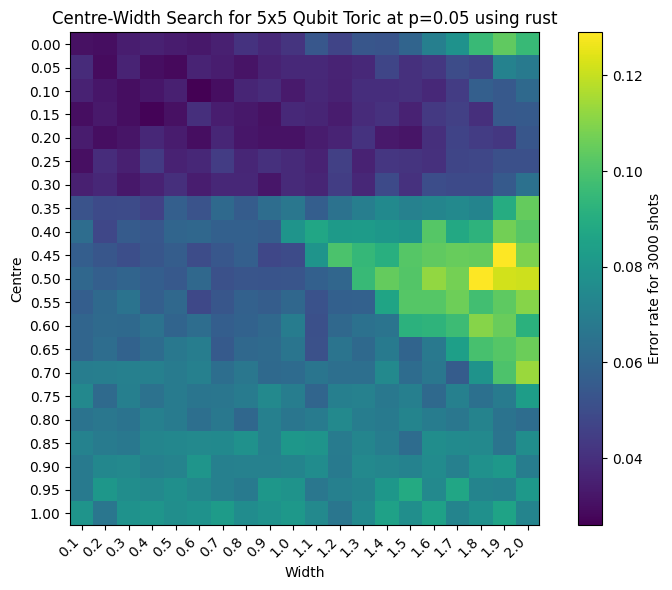

In [ ]:
results = np.array([[ 92.,  90., 103., 106., 102.,  98., 105., 123., 114., 125., 162., 141., 161., 158., 177., 211., 236., 288., 311., 286.],
       [116.,  87., 109.,  89.,  86., 109., 103.,  94., 108., 114., 114., 109., 114., 143., 121., 128., 150., 142., 215., 204.],
       [107.,  97.,  90.,  97., 105.,  78.,  90., 110., 116., 100., 113., 108., 118., 119., 121., 114., 133., 172., 164., 184.],
       [ 89.,  99.,  90.,  81.,  92., 120., 103.,  98.,  92., 114., 110., 101., 116., 122., 108., 129., 136., 120., 164., 166.],
       [102.,  89.,  96., 113., 101.,  89., 111.,  97.,  93.,  93., 102., 109., 123.,  99.,  96., 120., 140., 133., 128., 161.],
       [ 91., 117., 105., 131., 107., 112., 133., 111., 121., 115., 107., 136., 107., 127., 124., 121., 142., 144., 153., 153.],
       [105., 112.,  98., 108., 120., 103., 113., 112.,  97., 115., 110., 134., 113., 147., 122., 151., 147., 147., 165., 193.],
       [157., 147., 149., 138., 172., 157., 184., 168., 188., 200., 170., 194., 210., 225., 214., 219., 224., 218., 269., 314.],
       [188., 144., 167., 162., 179., 181., 173., 173., 169., 238., 261.,
        246., 248., 242., 237., 306., 265., 278., 321., 307.],
       [170., 161., 152., 161., 169., 150., 162., 172., 144., 149., 238.,
        300., 284., 273., 305., 312., 315., 314., 387., 326.],
       [181., 171., 178., 170., 164., 182., 155., 159., 158., 160., 173.,
        180., 286., 314., 304., 337., 323., 387., 366., 364.],
       [170., 184., 196., 171., 183., 145., 161., 174., 169., 181., 156.,
        173., 174., 259., 306., 305., 319., 293., 310., 331.],
       [179., 185., 184., 194., 177., 189., 170., 175., 182., 208., 153.,
        183., 193., 197., 277., 279., 290., 331., 316., 275.],
       [179., 189., 175., 187., 202., 209., 165., 183., 185., 198., 155.,
        197., 184., 204., 178., 203., 253., 297., 305., 318.],
       [209., 210., 212., 212., 207., 213., 190., 200., 184., 186., 198.,
        191., 191., 224., 187., 200., 168., 237., 301., 341.],
       [222., 185., 211., 195., 207., 198., 199., 206., 224., 209., 179.,
        211., 214., 202., 211., 184., 212., 192., 207., 250.],
       [196., 200., 196., 212., 206., 191., 202., 181., 212., 199., 207.,
        223., 209., 204., 217., 208., 201., 216., 196., 189.],
       [215., 207., 202., 219., 221., 223., 225., 234., 213., 241., 238.,
        207., 219., 209., 187., 230., 226., 224., 197., 230.],
       [204., 221., 223., 212., 216., 239., 213., 214., 214., 217., 228.,
        204., 223., 220., 215., 227., 213., 234., 243., 209.],
       [205., 241., 229., 223., 232., 222., 213., 204., 242., 237., 200.,
        213., 218., 241., 267., 223., 261., 218., 215., 244.],
       [238., 199., 236., 239., 231., 235., 248., 228., 235., 243., 224.,
        199., 225., 255., 231., 255., 217., 233., 257., 218.]])

centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 3000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 3000 shots")

ax.set_title("Centre-Width Search for 5x5 Qubit Toric at p=0.05 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


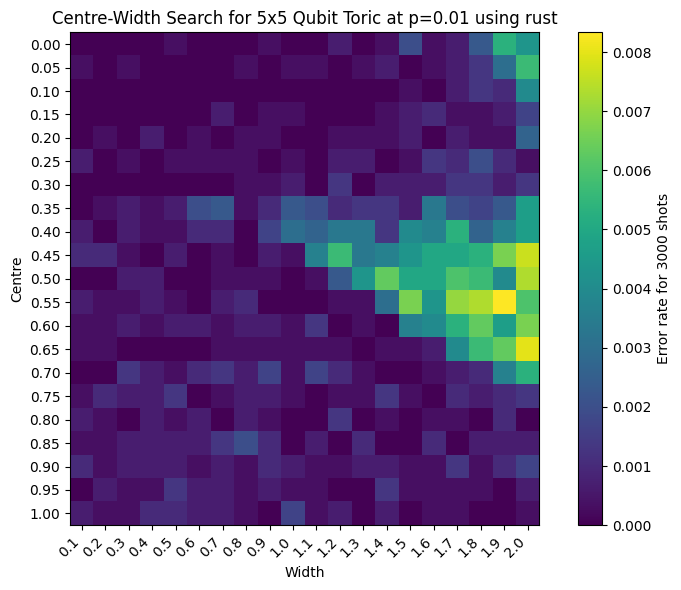

In [ ]:
results = np.array([[ 0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  2.,  0., 1.,  6.,  1.,  2.,  7., 16., 13.],
       [ 1.,  0.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  1.,  1.,  0.,  1., 2.,  0.,  1.,  2.,  4.,  9., 17.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 0.,  1.,  0.,  2.,  4.,  3., 12.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  1.,  1.,  0.,  0.,  0., 1.,  2.,  3.,  1.,  1.,  2.,  5.],
       [ 0.,  1.,  0.,  2.,  0.,  1.,  0.,  1.,  1.,  0.,  0.,  1.,  1., 1.,  2.,  0.,  2.,  1.,  1.,  8.],
       [ 2.,  0.,  1.,  0.,  1.,  1.,  1.,  1.,  0.,  1.,  0.,  2.,  2., 0.,  1.,  4.,  3.,  6.,  3.,  1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  2.,  0.,  4.,  0., 2.,  2.,  2.,  4.,  4.,  2.,  4.],
       [ 0.,  1.,  2.,  1.,  2.,  6.,  7.,  1.,  3.,  7.,  6.,  3.,  4., 4.,  2., 10.,  6.,  5.,  7., 14.],
       [ 2.,  0.,  2.,  1.,  1.,  3.,  3.,  0.,  5.,  9.,  8., 10., 10., 4., 12., 11., 16.,  8., 11., 14.],
       [ 3.,  3.,  1.,  0.,  2.,  0.,  1.,  0.,  2.,  1., 11., 17., 10., 11., 13., 15., 15., 16., 20., 23.],
       [ 0.,  0.,  2.,  2.,  0.,  0.,  1.,  1.,  1.,  0.,  1.,  7., 13., 19., 15., 15., 18., 17., 12., 22.],
       [ 2.,  1.,  1.,  2.,  1.,  0.,  2.,  3.,  0.,  0.,  0.,  1.,  1., 9., 20., 13., 21., 22., 25., 18.],
       [ 1.,  1.,  2.,  1.,  2.,  2.,  1.,  2.,  2.,  1.,  4.,  0.,  1., 0., 11., 12., 16., 19., 14., 20.],
       [ 1.,  1.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,  1.,  1.,  1.,  0., 1.,  1.,  2., 12., 17., 19., 24.],
       [ 0.,  0.,  4.,  2.,  1.,  3.,  4.,  2.,  5.,  1.,  5.,  3.,  1., 0.,  0.,  1.,  2.,  3., 11., 16.],
       [ 1.,  3.,  2.,  2.,  4.,  0.,  1.,  2.,  2.,  1.,  0.,  1.,  1., 4.,  1.,  0.,  3.,  2.,  3.,  4.],
       [ 2.,  1.,  0.,  2.,  1.,  2.,  0.,  2.,  1.,  0.,  0.,  4.,  0., 1.,  0.,  1.,  1.,  0.,  3.,  0.],
       [ 1.,  1.,  2.,  2.,  2.,  2.,  4.,  6.,  3.,  0.,  2.,  0.,  3., 0.,  0.,  3.,  0.,  2.,  2.,  2.],
       [ 3.,  1.,  2.,  2.,  2.,  1.,  2.,  1.,  3.,  2.,  1.,  1.,  2., 2.,  1.,  1.,  4.,  1.,  3.,  5.],
       [ 0.,  2.,  1.,  1.,  4.,  2.,  2.,  1.,  2.,  1.,  1.,  0.,  0., 4.,  1.,  1.,  1.,  1.,  0.,  2.],
       [ 2.,  1.,  1.,  3.,  3.,  2.,  2.,  1.,  0.,  5.,  1.,  2.,  0., 2.,  0.,  1.,  1.,  0.,  0.,  1.]])

centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 3000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 3000 shots")

ax.set_title("Centre-Width Search for 5x5 Qubit Toric at p=0.01 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[ 12.,  21.,  14.,  15.,  20.,  17.,  29.,  24.,  23.,  26.,  20.,
         34.,  32.,  34.,  36.,  64.,  70.,  68.,  82.,  97.],
       [ 22.,  17.,  16.,  21.,  24.,  21.,  16.,  16.,  14.,  19.,  39.,
         33.,  31.,  24.,  24.,  22.,  37.,  49.,  63.,  84.],
       [ 24.,  12.,  15.,  10.,  12.,  22.,  15.,  15.,  20.,  21.,  15.,
         17.,  21.,  19.,  21.,  20.,  24.,  28.,  57.,  62.],
       [ 17.,  26.,  16.,  18.,  20.,  13.,  23.,  23.,  26.,  18.,  26.,
         21.,  28.,  17.,  23.,  22.,  26.,  22.,  46.,  48.],
       [ 17.,  12.,  19.,  19.,  19.,  14.,  20.,  13.,  16.,  27.,  27.,
         23.,  24.,  16.,  26.,  19.,  29.,  25.,  33.,  43.],
       [ 28.,  28.,  24.,  24.,  27.,  27.,  16.,  15.,  15.,  30.,  21.,
         21.,  17.,  28.,  31.,  27.,  35.,  37.,  31.,  48.],
       [ 16.,  19.,  24.,  22.,  16.,  19.,  18.,  17.,  20.,  22.,  20.,
         16.,  30.,  30.,  35.,  26.,  36.,  29.,  50.,  58.],
       [ 53.,  46.,  39.,  45.,  36.,  32

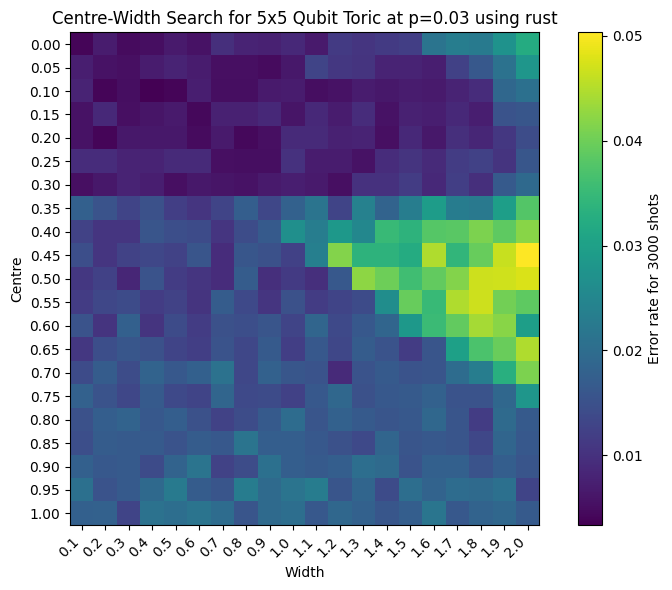

In [ ]:
centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 3000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 3000 shots")

ax.set_title("Centre-Width Search for 5x5 Qubit Toric at p=0.03 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[  9.,   6.,   2.,   6.,   5.,   8.,   5.,   6.,   8.,   9.,  12.,
         12.,  24.,  29.,  78., 103., 110., 121., 144., 116.],
       [  8.,   5.,   6.,   5.,   8.,  11.,   8.,   4.,   6.,   8.,   7.,
          7.,  11.,  16.,  25.,  29.,  62.,  94.,  95., 102.],
       [  3.,   4.,   5.,   2.,   1.,   5.,   4.,   9.,   4.,  11.,   8.,
          5.,   8.,  10.,  11.,  21.,  37.,  74.,  76.,  98.],
       [  4.,   6.,   4.,   9.,   3.,   1.,   4.,   7.,   8.,   6.,   9.,
          9.,  13.,  10.,   7.,  14.,  10.,  33.,  56.,  85.],
       [  4.,   6.,   9.,   4.,   9.,   5.,   8.,   6.,   6.,   7.,   7.,
         11.,   7.,   7.,  12.,  19.,  12.,  17.,  37.,  58.],
       [  6.,   6.,   7.,   6.,   9.,   9.,   6.,   8.,   7.,   8.,   7.,
          8.,  10.,   7.,  15.,  12.,  14.,  23.,  34.,  53.],
       [  9.,   6.,   7.,  13.,  11.,  10.,   9.,   8.,  16.,  10.,   7.,
         10.,   8.,  13.,  12.,   9.,  11.,  24.,  52.,  68.],
       [ 13.,  15.,  19.,  10.,   8.,  18

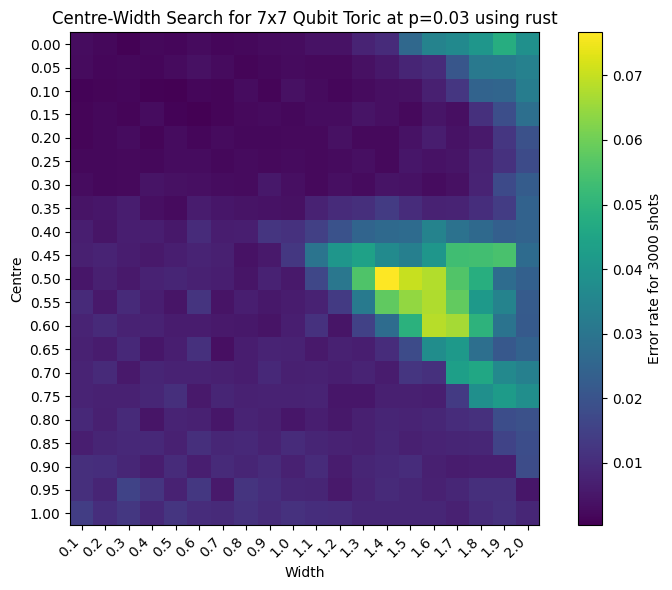

In [ ]:
centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 3000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 3000 shots")

ax.set_title("Centre-Width Search for 7x7 Qubit Toric at p=0.03 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[ 10.,   5.,   3.,   3.,   2.,   5.,   5.,   4.,   7.,  11.,  27.,
         55.,  97., 128., 166., 162., 169., 145., 147., 161.],
       [  7.,   6.,   4.,   1.,   1.,   4.,   4.,   6.,   5.,   1.,   3.,
          8.,  37.,  62.,  99., 123., 123., 118., 135., 121.],
       [  7.,   4.,   1.,   1.,   1.,   4.,   6.,   2.,   3.,   0.,   5.,
          1.,  16.,  36.,  84., 124., 124., 128., 132., 137.],
       [  4.,   2.,   1.,   1.,   3.,   2.,   1.,   2.,   0.,   3.,   3.,
          3.,   3.,   6.,  35.,  65.,  97.,  98.,  84., 109.],
       [  5.,   5.,   3.,   1.,   1.,   6.,   2.,   1.,   2.,   3.,   2.,
          3.,   2.,   6.,   5.,  14.,  40.,  60.,  69.,  61.],
       [  1.,  11.,  10.,   0.,   3.,   1.,   2.,   1.,   4.,   0.,   1.,
          2.,   7.,   4.,   6.,   5.,  30.,  45.,  70.,  73.],
       [  8.,   3.,   2.,   6.,   1.,   2.,   6.,   8.,   5.,   5.,   8.,
          7.,   9.,   9.,   6.,   9.,  19.,  60.,  75.,  74.],
       [  9.,  11.,  13.,  12.,  11.,   5

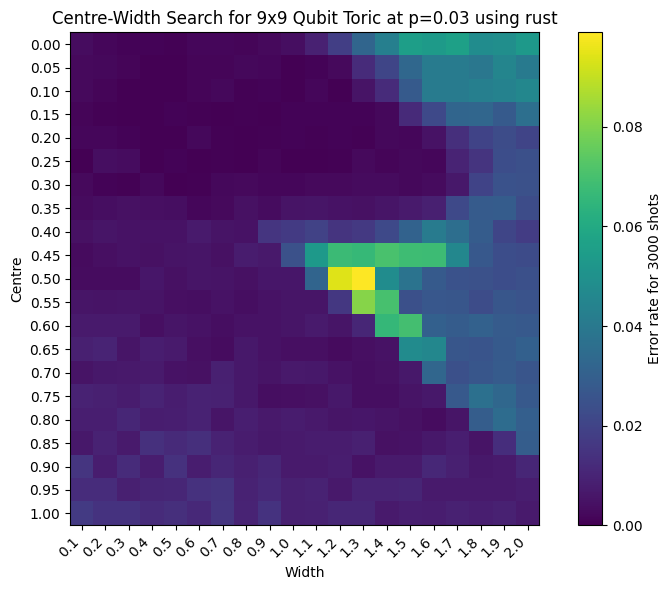

In [ ]:
centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 3000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 3000 shots")

ax.set_title("Centre-Width Search for 9x9 Qubit Toric at p=0.03 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


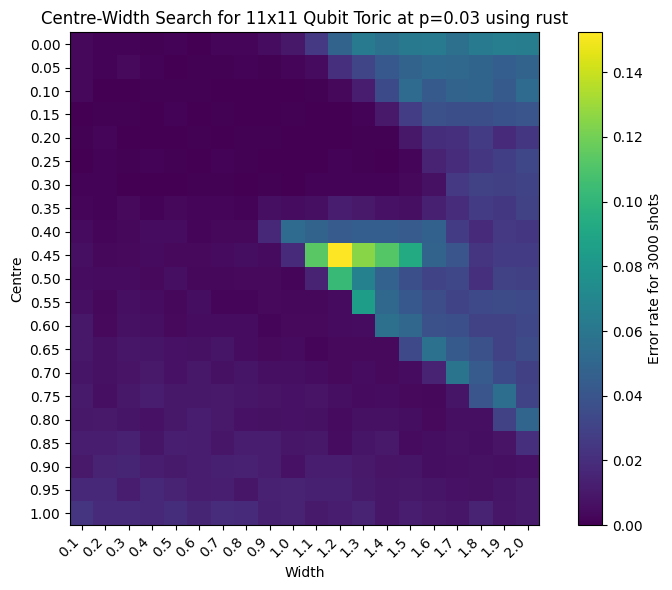

In [ ]:
results = np.array([[  9.,   4.,   4.,   3.,   4.,   1.,   6.,   6.,  15.,  29.,  75.,
        146., 186., 171., 184., 187., 168., 188., 195., 194.],
       [ 10.,   4.,  12.,   5.,   1.,   2.,   2.,   4.,   2.,   6.,  13.,
         64.,  96., 126., 146., 156., 154., 148., 137., 145.],
       [ 10.,   0.,   1.,   3.,   2.,   2.,   1.,   1.,   1.,   0.,   2.,
          9.,  37., 102., 159., 130., 146., 148., 130., 159.],
       [  0.,   2.,   2.,   1.,   5.,   0.,   3.,   0.,   1.,   3.,   1.,
          1.,   5.,  32.,  83., 113., 110., 109., 115., 121.],
       [  3.,   8.,   0.,   1.,   1.,   2.,   1.,   2.,   3.,   1.,   1.,
          0.,   2.,   2.,  29.,  60.,  64.,  80.,  55.,  73.],
       [  1.,   4.,   3.,   5.,   2.,   1.,   5.,   2.,   0.,   0.,   1.,
          4.,   2.,   1.,   6.,  43.,  58.,  72.,  84.,  98.],
       [  5.,   5.,   1.,   1.,   1.,   2.,   2.,   1.,   3.,   0.,   5.,
          5.,   4.,   4.,   9.,  20.,  76.,  88.,  86.,  93.],
       [  8.,   4.,  12.,   5.,   9.,   6.,   7.,   4.,  19.,  15.,  19.,
         37.,  31.,  22.,  19.,  40.,  58.,  80.,  74.,  88.],
       [ 13.,   8.,  10.,  15.,  15.,   7.,  10.,   9.,  53., 160., 145.,
        131., 136., 137., 132., 142.,  81.,  54.,  76.,  73.],
       [ 19.,  10.,  11.,  14.,  11.,  12.,  14.,  17.,  14.,  54., 340.,
        457., 375., 336., 280., 145., 121.,  71.,  82.,  82.],
       [ 15.,  13.,  13.,  11.,  18.,   9.,   9.,  12.,  12.,   8.,  44.,
        310., 201., 143., 112.,  93.,  98.,  64.,  90.,  87.],
       [ 19.,  10.,  18.,  15.,   9.,  17.,   8.,   8.,  12.,  10.,   9.,
         14., 254., 154., 126., 108.,  93., 101., 107., 100.],
       [ 30.,  11.,  21.,  19.,  12.,  16.,  16.,  15.,   6.,  11.,  11.,
         14.,  15., 168., 151., 113., 111.,  90.,  90.,  98.],
       [ 29.,  21.,  27.,  26.,  22.,  21.,  25.,  16.,  11.,  13.,   7.,
         11.,  11.,  12., 100., 171., 129., 114.,  88., 104.],
       [ 25.,  20.,  24.,  32.,  22.,  29.,  20.,  25.,  19.,  18.,  15.,
         11.,  16.,  12.,  15.,  45., 175., 132., 103.,  87.],
       [ 33.,  19.,  30.,  35.,  29.,  29.,  32.,  27.,  24.,  22.,  24.,
         19.,  14.,  16.,  11.,  10.,  25., 121., 165.,  93.],
       [ 29.,  31.,  26.,  23.,  30.,  34.,  32.,  23.,  21.,  22.,  20.,
         13.,  21.,  20.,  17.,  11.,  19.,  19.,  88., 149.],
       [ 34.,  36.,  42.,  25.,  38.,  37.,  28.,  37.,  34.,  27.,  30.,
         15.,  26.,  31.,  14.,  17.,  20.,  17.,  24.,  61.],
       [ 32.,  46.,  47.,  34.,  33.,  34.,  40.,  42.,  36.,  22.,  35.,
         35.,  31.,  24.,  25.,  17.,  18.,  20.,  18.,  22.],
       [ 51.,  52.,  36.,  51.,  45.,  34.,  38.,  28.,  42.,  46.,  40.,
         40.,  33.,  27.,  30.,  26.,  23.,  20.,  26.,  33.],
       [ 68.,  54.,  54.,  50.,  59.,  47.,  58.,  54.,  41.,  44.,  33.,
         37.,  44.,  28.,  37.,  31.,  28.,  43.,  28.,  33.]])

centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 3000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 3000 shots")

ax.set_title("Centre-Width Search for 11x11 Qubit Toric at p=0.03 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[128.,  76.,  66., ...,  98., 112.,  98.],
       [ 95.,  65.,  51., ...,  84., 105., 119.],
       [ 57.,  63.,  53., ...,  96., 104.,  98.],
       ...,
       [117., 127., 133., ..., 117., 116., 111.],
       [182., 193., 158., ..., 175., 182., 184.],
       [189., 178., 212., ..., 182., 222., 198.]], shape=(101, 100))

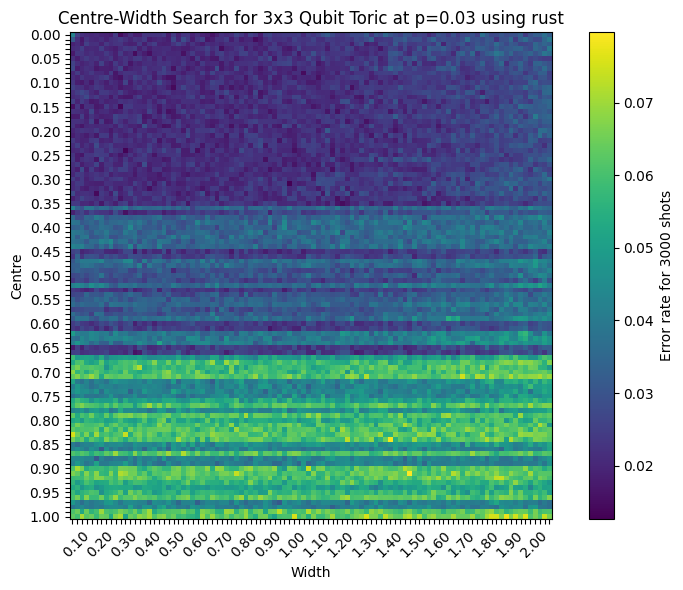

In [ ]:
centre = np.linspace(0.0, 1, 101)
width = np.linspace(0.0, 2, 101)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 3000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
yticks = [f'{c:.2f}' if ci%5==0 else '' for ci, c in enumerate(centre)]
xticks = [f'{w:.2f}' if (wi+1)%5==0 else '' for wi, w in enumerate(width)]

ax.set_yticklabels(yticks)
ax.set_xticklabels(xticks)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 3000 shots")

ax.set_title("Centre-Width Search for 3x3 Qubit Toric at p=0.03 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[156., 176., 142., 160., 151., 137., 134., 158., 150., 141., 144.,
        146., 149., 166., 143., 150., 164., 150., 158., 139.],
       [146., 147., 142., 137., 159., 150., 143., 152., 157., 141., 137.,
        151., 164., 151., 165., 151., 147., 155., 137., 144.],
       [148., 148., 165., 151., 157., 159., 169., 160., 160., 153., 176.,
        143., 147., 136., 124., 146., 158., 151., 141., 151.],
       [146., 156., 129., 137., 152., 154., 125., 157., 156., 156., 168.,
        136., 131., 157., 146., 137., 166., 153., 139., 153.],
       [135., 160., 136., 130., 164., 149., 155., 147., 138., 141., 167.,
        156., 158., 163., 156., 157., 143., 131., 146., 140.],
       [137., 137., 153., 159., 152., 147., 164., 158., 143., 178., 159.,
        143., 130., 144., 140., 135., 146., 132., 159., 159.],
       [157., 154., 161., 156., 153., 133., 148., 137., 153., 141., 134.,
        141., 148., 177., 168., 150., 151., 155., 167., 159.],
       [155., 157., 119., 134., 141., 172

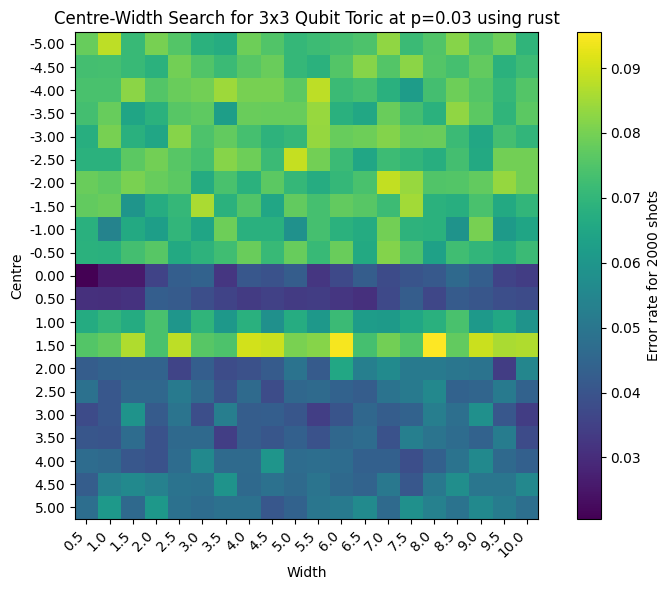

In [ ]:
centre = np.linspace(-5, 5, 21)
width = np.linspace(0.0, 10, 21)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 2000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 2000 shots")

ax.set_title("Centre-Width Search for 3x3 Qubit Toric at p=0.03 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
results


array([[ 53.,  47.,  45.,  39.,  36.,  44.,  48.,  33.,  40.,  42.,  43.,
         42.,  35.,  46.,  39.,  38.,  43.,  47.,  40.,  36.],
       [ 42.,  49.,  42.,  40.,  45.,  45.,  42.,  38.,  38.,  46.,  41.,
         46.,  44.,  41.,  61.,  41.,  51.,  38.,  46.,  42.],
       [ 43.,  37.,  54.,  47.,  52.,  44.,  47.,  61.,  46.,  31.,  45.,
         45.,  38.,  44.,  48.,  34.,  46.,  38.,  51.,  62.],
       [ 43.,  46.,  42.,  41.,  45.,  36.,  55.,  27.,  34.,  38.,  52.,
         32.,  40.,  46.,  34.,  52.,  49.,  43.,  40.,  50.],
       [ 36.,  34.,  42.,  44.,  31.,  37.,  43.,  39.,  44.,  46.,  42.,
         42.,  42.,  51.,  36.,  37.,  40.,  47.,  43.,  45.],
       [ 38.,  48.,  39.,  41.,  46.,  29.,  32.,  49.,  37.,  42.,  38.,
         41.,  34.,  49.,  45.,  49.,  63.,  46.,  53.,  50.],
       [ 47.,  43.,  42.,  44.,  34.,  40.,  44.,  40.,  58.,  44.,  49.,
         49.,  44.,  43.,  41.,  44.,  37.,  41.,  37.,  57.],
       [ 39.,  46.,  37.,  47.,  37.,  49

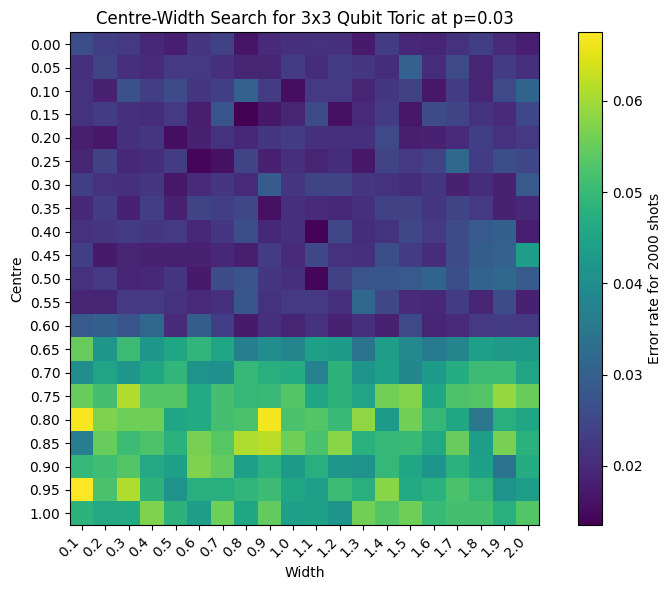

In [ ]:
centre = np.arange(0.0, 1.05, 0.05)
width = np.arange(0.1, 2.1, 0.1)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 2000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 2000 shots")

ax.set_title("Centre-Width Search for 3x3 Qubit Toric at p=0.03")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [45]:
# Using rust!
results


array([[214., 206., 203., ..., 352., 343., 340.],
       [217., 202., 204., ..., 318., 317., 317.],
       [243., 201., 205., ..., 288., 289., 288.],
       ...,
       [530., 550., 587., ..., 502., 577., 556.],
       [594., 555., 564., ..., 591., 568., 579.],
       [603., 620., 617., ..., 683., 673., 652.]], shape=(41, 40))

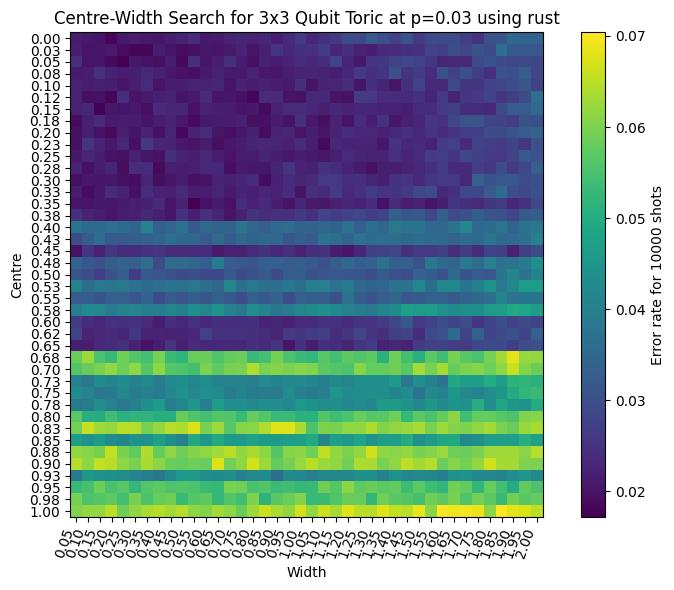

In [48]:
centre = np.linspace(0.0, 1, 41)
width = np.linspace(0.0, 2, 41)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 10000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.2f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=70, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 10000 shots")

ax.set_title("Centre-Width Search for 3x3 Qubit Toric at p=0.03 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


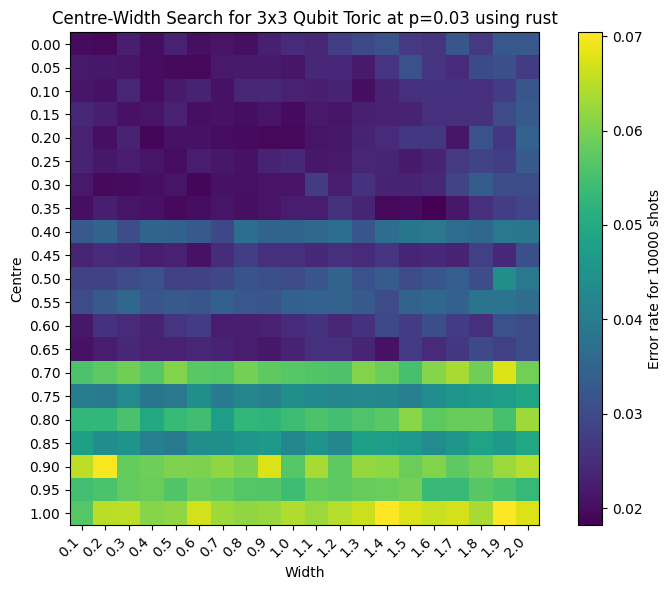

In [ ]:
results = np.array([[197., 194., 225., 201., 229., 204., 209., 203., 227., 246., 239., 278., 297., 311., 269., 260., 321., 268., 325., 324.],
       [218., 215., 212., 199., 195., 193., 217., 219., 220., 213., 243., 243., 219., 260., 312., 260., 247., 300., 309., 274.],
       [214., 207., 239., 200., 219., 231., 208., 238., 243., 230., 226., 232., 201., 234., 253., 259., 259., 254., 275., 322.],
       [243., 225., 207., 210., 230., 204., 208., 201., 211., 197., 217., 212., 228., 229., 231., 252., 255., 257., 304., 328.],
       [229., 204., 234., 189., 208., 207., 200., 197., 193., 194., 212., 215., 231., 245., 266., 266., 214., 313., 266., 346.],
       [231., 216., 222., 212., 199., 224., 215., 208., 234., 241., 215., 217., 238., 236., 220., 233., 268., 286., 279., 328.],
       [217., 196., 198., 204., 211., 190., 207., 206., 209., 210., 275., 225., 256., 235., 233., 242., 290., 335., 306., 304.],
       [204., 226., 211., 207., 195., 201., 211., 204., 210., 221., 222., 259., 236., 194., 198., 182., 215., 255., 277., 292.],
       [327., 348., 305., 350., 344., 327., 295., 370., 351., 350., 359., 370., 321., 369., 385., 389., 367., 358., 390., 387.],
       [236., 247., 242., 221., 229., 207., 249., 278., 253., 255., 242., 254., 246., 263., 237., 241., 231., 280., 241., 309.],
       [284., 284., 303., 314., 281., 282., 293., 318., 310., 301., 320., 348., 313., 331., 303., 319., 339., 305., 440., 392.],
       [301., 328., 358., 319., 327., 322., 342., 324., 320., 344., 347., 347., 330., 301., 349., 359., 345., 382., 381., 369.],
       [215., 258., 247., 235., 262., 273., 221., 225., 230., 244., 259., 238., 257., 297., 273., 307., 274., 254., 314., 303.],
       [207., 221., 240., 229., 229., 239., 234., 222., 216., 233., 254., 254., 236., 208., 270., 245., 266., 298., 280., 303.],
       [559., 573., 590., 568., 606., 570., 567., 595., 575., 569., 562., 558., 606., 585., 553., 609., 636., 590., 676., 593.],
       [401., 399., 434., 385., 389., 442., 400., 420., 410., 442., 429., 423., 428., 423., 408., 435., 458., 462., 474., 489.],
       [527., 527., 555., 499., 531., 543., 475., 527., 523., 539., 559., 547., 560., 570., 612., 573., 583., 582., 553., 627.],
       [478., 438., 452., 410., 399., 440., 443., 459., 464., 422., 452., 423., 478., 472., 461., 434., 458., 485., 465., 496.],
       [651., 698., 580., 589., 604., 602., 618., 602., 675., 566., 635., 574., 622., 615., 587., 606., 575., 594., 625., 646.],
       [547., 557., 579., 587., 563., 588., 580., 566., 564., 542., 581., 574., 582., 585., 594., 533., 535., 569., 554., 532.],
       [566., 650., 653., 609., 618., 669., 628., 617., 624., 641., 626., 646., 662., 704., 677., 661., 670., 635., 704., 677.]])

centre = np.arange(0.0, 1.05, 0.05)
width = np.arange(0.1, 2.1, 0.1)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 10000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 10000 shots")

ax.set_title("Centre-Width Search for 3x3 Qubit Toric at p=0.03 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


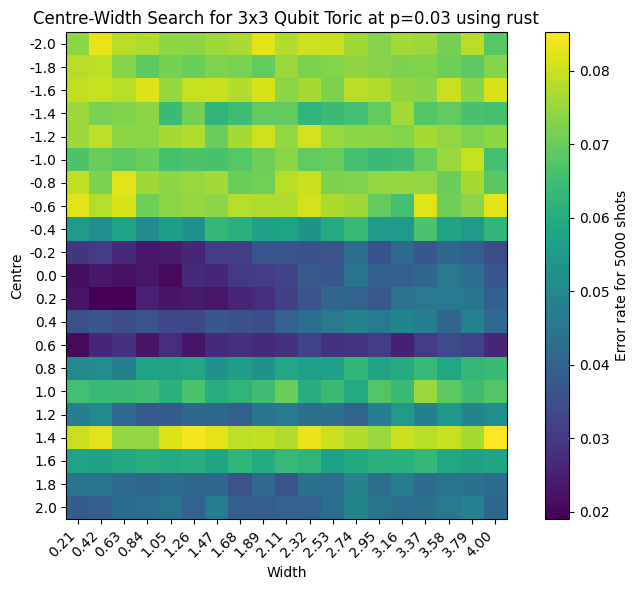

In [ ]:
results = np.array([[370., 415., 390., 387., 370., 368., 377., 384., 412., 386., 401., 400., 379., 365., 380., 376., 357., 391., 340.],
       [390., 393., 366., 343., 358., 352., 362., 359., 346., 376., 361., 364., 371., 366., 361., 363., 353., 343., 366.],
       [395., 398., 391., 408., 374., 397., 399., 388., 406., 369., 381., 361., 392., 387., 371., 367., 399., 367., 406.],
       [377., 359., 363., 369., 321., 357., 312., 323., 347., 347., 313., 322., 327., 346., 380., 338., 346., 331., 330.],
       [378., 393., 368., 368., 382., 386., 350., 381., 402., 372., 403., 375., 369., 368., 364., 382., 372., 362., 370.],
       [335., 351., 343., 350., 330., 333., 331., 339., 353., 368., 345., 349., 329., 321., 325., 349., 376., 397., 327.],
       [395., 361., 411., 379., 370., 375., 380., 352., 356., 391., 400., 361., 362., 372., 374., 372., 350., 382., 341.],
       [410., 389., 406., 353., 369., 374., 369., 389., 386., 386., 403., 385., 379., 346., 327., 410., 354., 368., 413.],
       [276., 258., 287., 254., 279., 265., 315., 305., 285., 287., 266., 297., 319., 275., 276., 332., 288., 275., 314.],
       [149., 152., 136., 117., 119., 130., 155., 155., 184., 183., 178., 180., 214., 179., 208., 185., 206., 194., 173.],
       [107., 118., 110., 116., 103., 135., 132., 151., 153., 161., 188., 185., 223., 197., 197., 204., 226., 216., 184.],
       [113.,  95.,  95., 125., 115., 119., 116., 131., 138., 158., 182., 204., 201., 187., 221., 228., 229., 225., 198.],
       [176., 182., 170., 180., 165., 167., 185., 177., 175., 199., 214., 226., 245., 232., 247., 237., 204., 242., 208.],
       [103., 132., 142., 112., 137., 114., 134., 140., 134., 144., 162., 144., 145., 153., 124., 153., 171., 162., 132.],
       [249., 256., 239., 287., 286., 294., 262., 281., 264., 294., 282., 285., 314., 288., 298., 318., 293., 316., 320.],
       [326., 318., 320., 324., 306., 332., 301., 312., 325., 350., 301., 320., 297., 337., 321., 376., 342., 324., 337.],
       [238., 254., 208., 190., 191., 207., 205., 197., 225., 233., 217., 219., 200., 238., 275., 240., 272., 246., 258.],
       [400., 411., 372., 372., 409., 422., 412., 393., 395., 386., 416., 399., 387., 376., 399., 391., 398., 381., 426.],
       [286., 285., 295., 303., 299., 303., 291., 313., 298., 319., 311., 285., 296., 306., 306., 315., 292., 284., 289.],
       [224., 224., 211., 206., 212., 205., 205., 180., 208., 180., 218., 213., 243., 217., 237., 211., 223., 219., 211.],
       [193., 196., 212., 214., 223., 199., 234., 195., 195., 199., 200., 215., 245., 224., 213., 218., 228., 242., 205.]])

centre = np.linspace(-2.0, 2.0, 21)
width = np.linspace(0.0, 4.0, 20)[1:]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 5000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.1f}' for c in centre])
ax.set_xticklabels([f'{w:.2f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 5000 shots")

ax.set_title("Centre-Width Search for 3x3 Qubit Toric at p=0.03 using rust")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
# p=0.03, qutrit, toric 3x3, big range, same rand
results


array([[31., 24., 36., 27., 21., 30., 30., 25., 28., 21., 25., 28., 26.,
        35., 19., 35., 29., 20., 34., 21.],
       [26., 23., 21., 24., 32., 23., 33., 36., 34., 15., 30., 29., 24.,
        27., 23., 24., 27., 31., 39., 37.],
       [36., 28., 35., 20., 30., 26., 26., 23., 27., 23., 27., 24., 25.,
        30., 22., 34., 40., 25., 22., 23.],
       [30., 19., 26., 20., 19., 23., 21., 33., 27., 31., 41., 29., 23.,
        22., 23., 20., 26., 25., 28., 27.],
       [29., 24., 23., 28., 20., 23., 31., 37., 18., 27., 28., 36., 34.,
        14., 32., 21., 28., 25., 29., 21.],
       [26., 27., 21., 22., 29., 34., 29., 24., 23., 29., 30., 27., 25.,
        20., 26., 23., 30., 22., 33., 34.],
       [19., 24., 18., 26., 16., 17., 14., 12., 16., 15., 20., 17., 10.,
        17., 15., 20., 12., 20., 16., 21.],
       [23., 16., 11., 15., 11., 15., 21., 17., 16., 27., 19., 11., 16.,
        17., 15., 15., 15., 17., 19., 17.],
       [17., 20., 16., 11., 14., 25., 18., 24., 24., 22., 15., 1

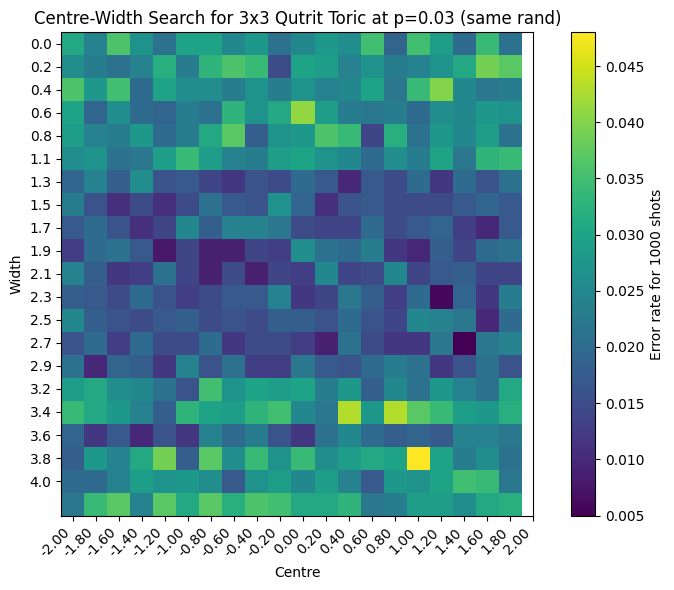

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 1000)

# Set ticks
ax.set_xticks(np.arange(len(centre)))
ax.set_yticks(np.arange(len(width)))

# Set tick labels
ax.set_xticklabels([f'{c:.2f}' for c in centre])
ax.set_yticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 1000 shots")

ax.set_title("Centre-Width Search for 3x3 Qutrit Toric at p=0.03 (same rand)")
ax.set_xlabel("Centre")
ax.set_ylabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
# p=0.03, qutrit, toric 3x3, big range, diff rand
results


array([[24., 25., 22., 24., 24., 30., 29., 35., 26., 31., 26., 29., 27.,
        32., 36., 27., 24., 24., 28., 31.],
       [28., 36., 30., 43., 30., 28., 34., 33., 21., 27., 26., 24., 34.,
        24., 27., 27., 25., 24., 36., 25.],
       [34., 25., 31., 23., 27., 20., 30., 25., 24., 29., 38., 38., 29.,
        33., 24., 25., 23., 25., 28., 34.],
       [28., 18., 32., 30., 29., 26., 26., 32., 33., 30., 34., 30., 19.,
        27., 25., 25., 34., 23., 29., 21.],
       [33., 25., 25., 23., 24., 29., 27., 26., 25., 22., 32., 20., 29.,
        20., 25., 15., 26., 29., 24., 26.],
       [25., 19., 29., 33., 32., 32., 28., 34., 30., 27., 31., 34., 29.,
        28., 29., 21., 29., 25., 20., 32.],
       [11., 12., 27., 17., 26., 14., 17., 19., 16., 21., 12., 12., 27.,
        13., 19., 16., 22., 25., 19., 21.],
       [21., 22., 28., 16., 22., 23., 18., 18., 20., 22., 14., 22., 15.,
        23., 26., 19., 16., 17., 17., 14.],
       [11., 20., 13., 16., 16., 13., 20., 15., 11., 20., 15., 1

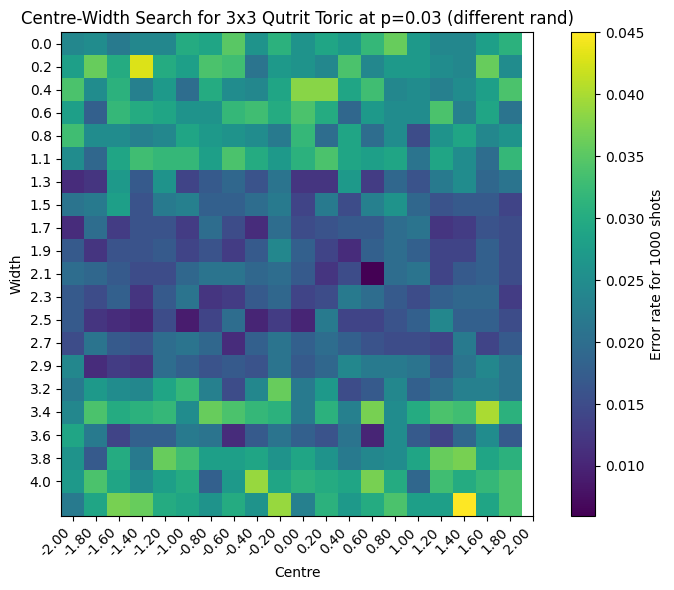

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 1000)

# Set ticks
ax.set_xticks(np.arange(len(centre)))
ax.set_yticks(np.arange(len(width)))

# Set tick labels
ax.set_xticklabels([f'{c:.2f}' for c in centre])
ax.set_yticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 1000 shots")

ax.set_title("Centre-Width Search for 3x3 Qutrit Toric at p=0.03 (different rand)")
ax.set_xlabel("Centre")
ax.set_ylabel("Width")

plt.tight_layout()
plt.show()


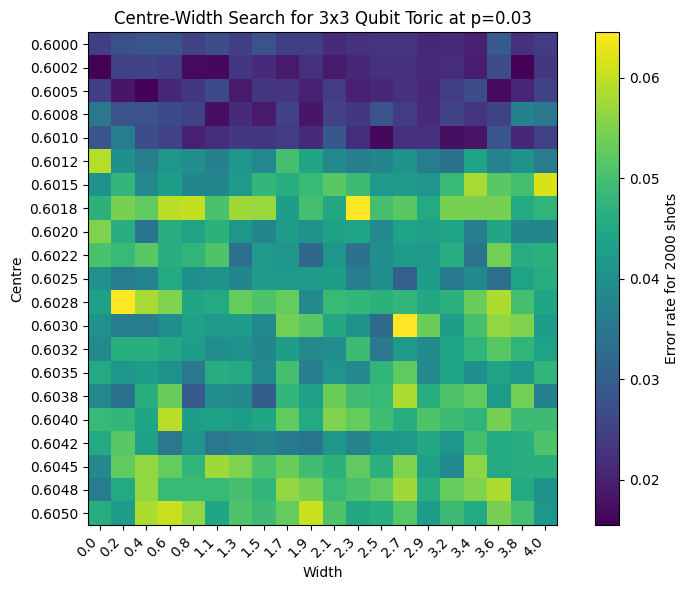

In [ ]:
results = np.array([[ 49.,  55.,  57.,  56.,  50.,  54.,  49.,  56.,  49.,  49.,  43., 45.,  46.,  46.,  42.,  43.,  40.,  59.,  45.,  48.],
       [ 31.,  50.,  51.,  49.,  34.,  33.,  47.,  43.,  38.,  45.,  38., 42.,  45.,  45.,  43.,  44.,  39.,  54.,  32.,  47.],
       [ 49.,  37.,  32.,  42.,  47.,  53.,  38.,  47.,  46.,  40.,  48., 40.,  42.,  45.,  42.,  49.,  54.,  34.,  41.,  51.],
       [ 70.,  56.,  56.,  53.,  50.,  35.,  43.,  38.,  50.,  37.,  50., 47.,  57.,  48.,  43.,  51.,  46.,  50.,  74.,  70.],
       [ 57.,  72.,  54.,  50.,  40.,  44.,  47.,  47.,  48.,  43.,  58., 44.,  33.,  45.,  45.,  35.,  36.,  57.,  42.,  50.],
       [118.,  80.,  72.,  82.,  80.,  74.,  83.,  78., 100.,  89.,  77., 73.,  76.,  81.,  72.,  68.,  88.,  75.,  81.,  72.],
       [ 81.,  96.,  77.,  86.,  76.,  76.,  84.,  96.,  92.,  97., 104., 98.,  84.,  85.,  82.,  97., 116., 104., 100., 123.],
       [ 94., 109., 105., 119., 120., 101., 115., 114.,  86., 100.,  90., 129., 100., 104.,  91., 109., 109., 109.,  91.,  95.],
       [110.,  93.,  69.,  92.,  88.,  94.,  83.,  76.,  85.,  81.,  87., 88.,  77.,  88.,  87.,  88.,  73.,  89.,  76.,  76.],
       [101.,  97., 104.,  92.,  95., 102.,  67.,  84.,  82.,  64.,  83., 68.,  79.,  85.,  84.,  92.,  69., 108.,  92.,  94.],
       [ 81.,  72.,  75.,  91.,  80.,  81.,  76.,  85.,  84.,  85.,  86., 73.,  79.,  61.,  86.,  71.,  78.,  67.,  88.,  92.],
       [ 87., 129., 116., 110.,  89.,  91., 106., 102., 106.,  77.,  97., 96.,  94.,  96.,  90.,  94., 107., 117., 100.,  89.],
       [ 81.,  72.,  72.,  79.,  87.,  84.,  85.,  78., 108., 104.,  90., 81.,  65., 129., 107.,  86., 100., 113., 110.,  86.],
       [ 77.,  93.,  93.,  90.,  86.,  79.,  81.,  76.,  86.,  77.,  79., 98.,  70.,  84.,  78.,  89.,  95., 104.,  95.,  88.],
       [ 91.,  83.,  86.,  81.,  70.,  92.,  91.,  78., 100.,  73.,  82., 77.,  95., 105.,  77.,  88.,  80.,  88.,  83.,  95.],
       [ 77.,  68.,  93., 107.,  59.,  79.,  78.,  60.,  96.,  87., 107., 99.,  97., 117.,  93., 102., 105.,  85., 108.,  74.],
       [ 97.,  96.,  89., 119.,  86.,  87.,  86.,  89., 105.,  91., 110., 106.,  99.,  92., 102.,  98.,  95., 109.,  98.,  98.],
       [ 91., 104.,  87.,  70.,  82.,  70.,  73.,  75.,  71.,  69.,  83., 75.,  83.,  84.,  90.,  83., 100.,  91.,  93., 102.],
       [ 77., 105., 113., 106.,  96., 115., 110., 101., 107.,  99.,  94., 105.,  94., 110.,  87.,  78., 112.,  91.,  93.,  93.],
       [ 72.,  91., 113.,  97.,  97.,  97., 100.,  96., 113., 109.,  97., 101., 105., 115.,  92., 106., 110., 117.,  91.,  81.],
       [ 92.,  85., 117., 121., 113.,  89., 102.,  98., 106., 121., 102., 90.,  93., 103.,  86.,  98.,  91., 109., 100.,  83.]])

centre = np.linspace(0.6, 0.605, 21)
width = np.linspace(0.0, 4.0, 20)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 2000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.4f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 2000 shots")

ax.set_title("Centre-Width Search for 3x3 Qubit Toric at p=0.03")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


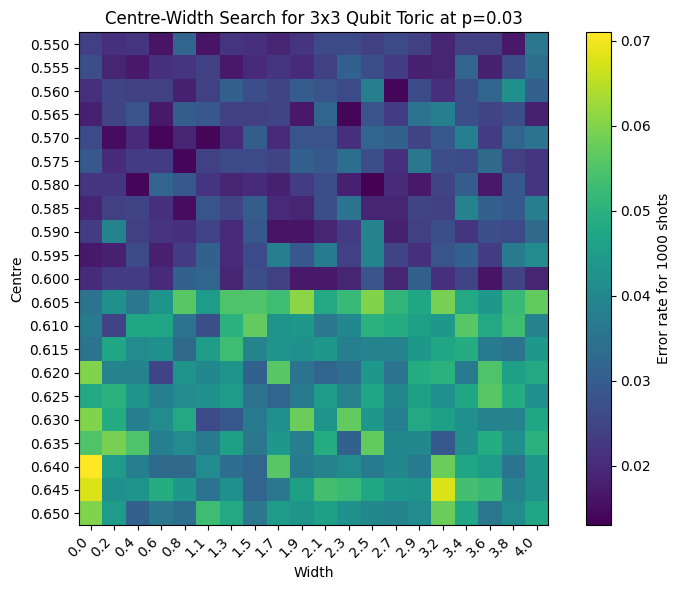

In [ ]:
results = np.array([[24., 21., 22., 16., 32., 16., 22., 21., 19., 22., 26., 26., 24., 26., 24., 19., 24., 24., 17., 36.],
       [27., 19., 17., 21., 22., 24., 17., 20., 22., 20., 24., 31., 27., 23., 18., 19., 32., 18., 27., 34.],
       [21., 25., 24., 24., 18., 24., 31., 27., 25., 30., 28., 26., 38., 14., 26., 21., 27., 32., 42., 31.],
       [18., 25., 28., 17., 30., 29., 24., 24., 25., 17., 32., 14., 28., 23., 35., 38., 27., 25., 27., 18.],
       [26., 15., 20., 14., 19., 14., 20., 30., 20., 28., 28., 21., 32., 31., 25., 29., 38., 23., 32., 35.],
       [29., 20., 23., 23., 14., 24., 26., 26., 25., 31., 29., 34., 27., 21., 36., 27., 26., 33., 24., 22.],
       [22., 22., 14., 32., 29., 22., 19., 20., 18., 23., 27., 18., 13., 20., 17., 25., 30., 17., 29., 22.],
       [19., 24., 25., 21., 15., 28., 25., 30., 20., 19., 27., 35., 19., 19., 25., 24., 39., 31., 29., 38.],
       [23., 39., 24., 22., 21., 25., 20., 29., 16., 16., 19., 23., 39., 18., 24., 27., 22., 27., 26., 33.],
       [17., 18., 26., 18., 23., 31., 20., 26., 38., 29., 37., 24., 39., 25., 21., 28., 31., 23., 37., 41.],
       [20., 23., 23., 20., 31., 32., 19., 27., 24., 17., 17., 19., 28., 19., 31., 21., 25., 16., 25., 19.],
       [35., 42., 36., 43., 56., 45., 55., 55., 53., 61., 48., 52., 60., 51., 47., 59., 48., 44., 52., 57.],
       [37., 25., 47., 47., 35., 27., 50., 57., 43., 44., 36., 40., 50., 49., 46., 44., 56., 48., 53., 39.],
       [35., 47., 41., 42., 33., 45., 53., 39., 43., 42., 44., 38., 39., 39., 44., 47., 49., 37., 35., 44.],
       [60., 39., 39., 25., 43., 40., 43., 31., 56., 35., 32., 34., 44., 35., 49., 50., 37., 55., 46., 48.],
       [48., 50., 43., 38., 41., 42., 45., 35., 32., 37., 45., 39., 47., 40., 46., 42., 47., 56., 49., 42.],
       [60., 49., 38., 41., 48., 26., 29., 37., 42., 58., 43., 57., 44., 38., 48., 46., 42., 39., 39., 47.],
       [55., 59., 55., 38., 41., 37., 46., 36., 44., 38., 49., 31., 57., 40., 40., 29., 42., 49., 42., 50.],
       [71., 45., 38., 33., 33., 41., 34., 32., 56., 37., 39., 41., 37., 40., 37., 58., 47., 45., 35., 44.],
       [68., 42., 43., 49., 44., 35., 42., 32., 36., 46., 54., 52., 47., 44., 43., 68., 54., 52., 39., 43.],
       [60., 45., 31., 36., 34., 53., 48., 36., 45., 43., 46., 42., 40., 39., 41., 58., 47., 36., 41., 47.]])

centre = np.linspace(0.55, 0.65, 21)
width = np.linspace(0.0, 4.0, 20)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 1000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.3f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 1000 shots")

ax.set_title("Centre-Width Search for 3x3 Qubit Toric at p=0.03")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


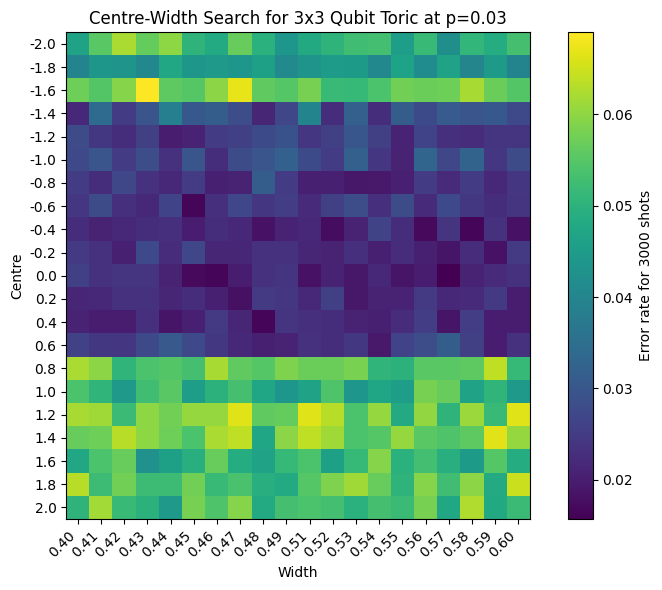

In [47]:
results = np.array([[139., 166., 187., 169., 180., 151., 145., 170., 149., 131., 144., 151., 158., 159., 136., 155., 127., 153., 146., 160.],
       [119., 132., 130., 122., 143., 132., 133., 131., 138., 123., 130., 135., 134., 122., 140., 125., 139., 120., 134., 119.],
       [172., 164., 178., 207., 167., 165., 179., 201., 168., 165., 174., 155., 154., 162., 173., 171., 172., 186., 171., 164.],
       [ 65., 103.,  75.,  89., 116.,  91.,  94.,  85.,  64.,  81., 119., 68.,  96.,  68.,  94.,  83.,  93.,  89.,  91.,  82.],
       [ 84.,  73.,  68.,  77.,  60.,  63.,  75.,  77.,  83.,  87.,  72., 77.,  90.,  77.,  63.,  79.,  69.,  67.,  71.,  71.],
       [ 82.,  89.,  75.,  85.,  70.,  89.,  68.,  84.,  89.,  96.,  83., 75.,  96.,  72.,  63.,  99.,  81.,  98.,  72.,  84.],
       [ 75.,  68.,  81.,  70.,  65.,  75.,  61.,  62.,  94.,  75.,  61., 61.,  57.,  58.,  61.,  75.,  66.,  75.,  65.,  72.],
       [ 72.,  84.,  69.,  65.,  79.,  50.,  69.,  81.,  72.,  76.,  66., 77.,  85.,  69.,  84.,  66.,  82.,  73.,  68.,  71.],
       [ 68.,  62.,  65.,  68.,  69.,  59.,  68.,  65.,  55.,  62.,  65., 52.,  62.,  80.,  68.,  51.,  71.,  50.,  70.,  55.],
       [ 74.,  70.,  61.,  82.,  67.,  81.,  64.,  64.,  70.,  70.,  64., 62.,  69.,  61.,  67.,  61.,  56.,  67.,  55.,  74.],
       [ 77.,  70.,  71.,  71.,  62.,  51.,  50.,  60.,  70.,  71.,  55., 63.,  57.,  65.,  56.,  60.,  47.,  62.,  66.,  70.],
       [ 64.,  65.,  70.,  70.,  64.,  68.,  61.,  54.,  74.,  72.,  65., 77.,  57.,  62.,  63.,  74.,  65.,  66.,  74.,  59.],
       [ 62.,  60.,  60.,  69.,  56.,  61.,  74.,  64.,  50.,  71.,  69., 68.,  63.,  61.,  67.,  76.,  56.,  76.,  60.,  59.],
       [ 78.,  73.,  72.,  82.,  92.,  82.,  73.,  65.,  61.,  63.,  70., 68.,  73.,  58.,  79.,  85.,  94.,  77.,  59.,  70.],
       [187., 179., 152., 162., 164., 160., 186., 168., 165., 176., 171., 171., 175., 152., 150., 166., 166., 167., 192., 154.],
       [162., 152., 133., 158., 166., 136., 150., 160., 141., 131., 139., 163., 131., 142., 136., 174., 170., 139., 152., 133.],
       [186., 184., 156., 180., 173., 182., 182., 199., 168., 169., 199., 190., 162., 182., 145., 181., 151., 183., 155., 199.],
       [170., 172., 190., 180., 172., 162., 187., 192., 142., 179., 192., 184., 162., 165., 182., 166., 163., 167., 200., 182.],
       [143., 162., 170., 128., 138., 147., 170., 146., 139., 154., 162., 138., 154., 178., 149., 159., 147., 134., 165., 146.],
       [190., 157., 173., 157., 157., 173., 155., 161., 147., 145., 165., 176., 184., 170., 151., 178., 158., 179., 145., 194.],
       [151., 185., 155., 150., 133., 174., 163., 178., 145., 160., 162., 159., 149., 160., 156., 174., 143., 188., 144., 156.]])

centre = np.linspace(-2.0, 2.0, 21)
width = np.linspace(0.4, 0.6, 20)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 3000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.1f}' for c in centre])
ax.set_xticklabels([f'{w:.2f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 3000 shots")

ax.set_title("Centre-Width Search for 3x3 Qubit Toric at p=0.03")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


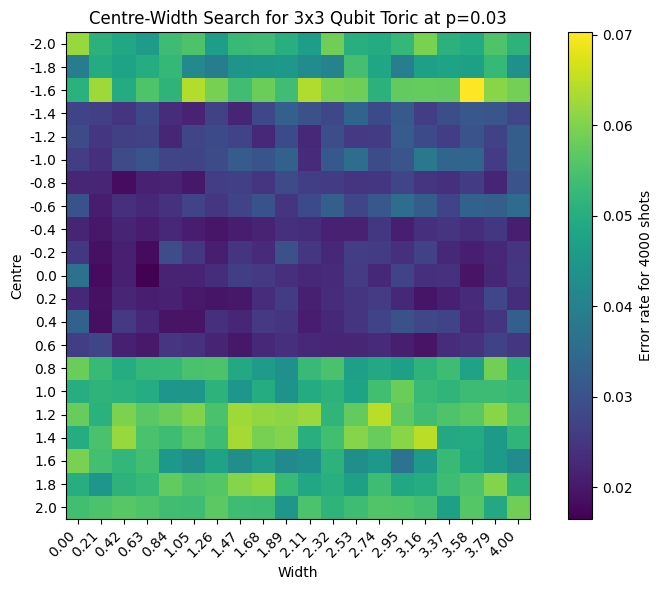

In [45]:
results = np.array([[248., 204., 195., 184., 214., 221., 186., 212., 213., 202., 186., 234., 202., 198., 209., 238., 204., 198., 222., 205.],
       [157., 198., 191., 199., 209., 167., 157., 177., 180., 181., 170., 162., 218., 193., 158., 187., 191., 188., 210., 174.],
       [203., 250., 198., 222., 206., 256., 237., 215., 233., 215., 255., 238., 234., 204., 229., 230., 229., 281., 243., 236.],
       [109., 107.,  99., 113.,  93.,  87., 108.,  88., 113., 132., 119., 113., 135., 114., 127., 105., 118., 124., 123., 112.],
       [115., 100., 107., 108.,  89., 111., 114., 109.,  90., 114.,  91., 117., 102., 103., 128., 114., 105., 121., 108., 129.],
       [105.,  95., 115., 122., 111., 110., 115., 128., 122., 133.,  92., 125., 143., 116., 123., 152., 136., 136., 104., 129.],
       [ 89.,  89.,  73.,  86.,  87.,  80., 106., 107.,  99., 116., 106., 103.,  99., 100., 111.,  99.,  95., 104.,  88., 121.],
       [120.,  83.,  96.,  90.,  97., 109., 100., 109., 120.,  99., 114., 131., 111., 124., 143., 129., 109., 133., 131., 141.],
       [ 88.,  80.,  88.,  83.,  90.,  82.,  79.,  82.,  87.,  95.,  94., 86.,  86., 101.,  84.,  95.,  99.,  94., 101.,  84.],
       [101.,  76.,  85.,  72., 117., 101.,  84.,  98.,  92., 119., 100., 91., 105., 104.,  95., 108.,  91.,  84.,  91.,  99.],
       [147.,  72.,  85.,  66.,  87.,  87.,  94., 106., 102.,  96.,  90., 92., 103.,  91., 109.,  95.,  97.,  77.,  89., 100.],
       [ 90.,  76.,  89.,  84.,  86.,  81.,  78.,  80.,  93., 103.,  85., 93.,  98., 104.,  91.,  78.,  85.,  92., 112.,  94.],
       [133.,  75., 102.,  90.,  77.,  77.,  96.,  89., 102.,  99.,  82., 90.,  98., 109., 119., 112., 109.,  91.,  99., 130.],
       [106., 111.,  85.,  81., 100.,  97.,  88.,  80.,  91.,  96.,  91., 89.,  89.,  92.,  84.,  77.,  93.,  97., 108., 100.],
       [233., 212., 199., 209., 210., 219., 221., 196., 184., 174., 212., 219., 187., 196., 188., 206., 214., 190., 235., 204.],
       [200., 206., 203., 199., 179., 180., 205., 179., 199., 176., 198., 205., 191., 216., 233., 211., 207., 213., 213., 210.],
       [231., 203., 239., 226., 232., 240., 219., 250., 246., 244., 249., 207., 229., 259., 228., 215., 222., 226., 243., 224.],
       [199., 219., 248., 219., 214., 225., 214., 252., 237., 241., 202., 216., 242., 231., 243., 259., 196., 198., 183., 207.],
       [238., 217., 208., 216., 181., 173., 190., 172., 184., 168., 174., 205., 173., 181., 148., 182., 211., 197., 183., 170.],
       [200., 179., 205., 210., 229., 221., 224., 242., 247., 212., 195., 201., 188., 214., 194., 199., 214., 222., 241., 204.],
       [216., 220., 225., 222., 215., 214., 227., 214., 213., 178., 220., 206., 214., 223., 222., 217., 187., 224., 196., 234.]])
centre = np.linspace(-2.0, 2.0, 21)
width = np.linspace(0.0, 4.0, 20)


fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 4000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.1f}' for c in centre])
ax.set_xticklabels([f'{w:.2f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 4000 shots")

ax.set_title("Centre-Width Search for 3x3 Qubit Toric at p=0.03")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [ ]:
# p=0.03, qutrit, toric 3x3, same rand
results


array([[18., 18., 17., 21.,  9., 24., 17., 14., 13., 16., 16., 17., 20.,
        15.,  8., 21., 14., 17., 15., 19.],
       [16.,  6., 23., 14., 13., 15., 21., 20., 12., 16., 12., 16., 13.,
        21., 16., 13., 13., 15., 14., 18.],
       [10.,  7., 17., 12., 15., 15., 20., 17., 11., 21., 14., 15., 16.,
        16., 15., 13., 14., 21., 14., 18.],
       [15., 19., 18., 16., 17., 10., 21., 24., 17., 15., 14., 17., 15.,
        21., 15., 10., 21., 13., 16., 15.],
       [15., 15.,  8.,  7., 13., 18., 14., 15., 19., 13., 13., 12., 20.,
        17., 19., 14., 13., 24., 19., 12.],
       [11., 18., 21., 19., 14., 18., 22., 18., 15., 10., 17., 16., 19.,
        19., 15., 21., 19., 17., 17., 12.],
       [18., 15., 12., 13., 18., 12., 11., 17., 12., 17., 14., 22., 12.,
         7., 15., 17., 16., 18., 15., 16.],
       [17., 17., 19., 13., 14., 17., 18., 16.,  9., 12., 21., 14., 12.,
        12., 11., 14., 19., 21., 14., 13.],
       [18., 14., 13., 11., 23., 17., 20., 15., 16., 13., 11., 1

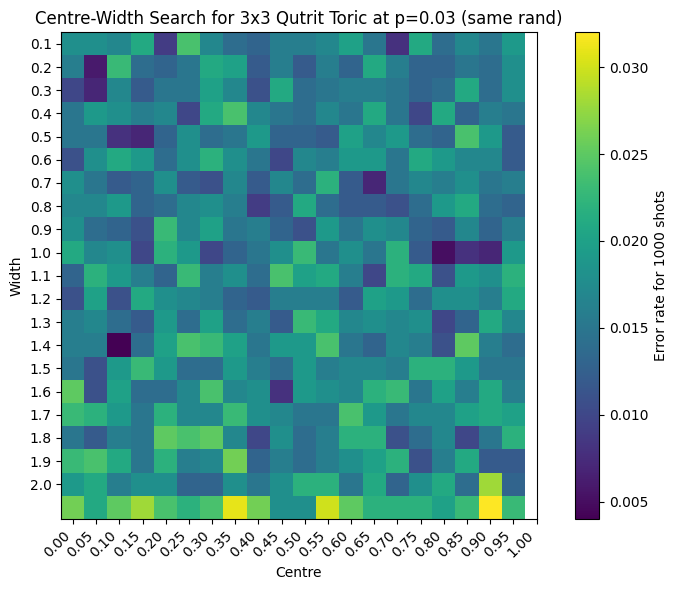

In [53]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 1000)

# Set ticks
ax.set_xticks(np.arange(len(centre)))
ax.set_yticks(np.arange(len(width)))

# Set tick labels
ax.set_xticklabels([f'{c:.2f}' for c in centre])
ax.set_yticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 1000 shots")

ax.set_title("Centre-Width Search for 3x3 Qutrit Toric at p=0.03 (same rand)")
ax.set_xlabel("Centre")
ax.set_ylabel("Width")

plt.tight_layout()
plt.show()


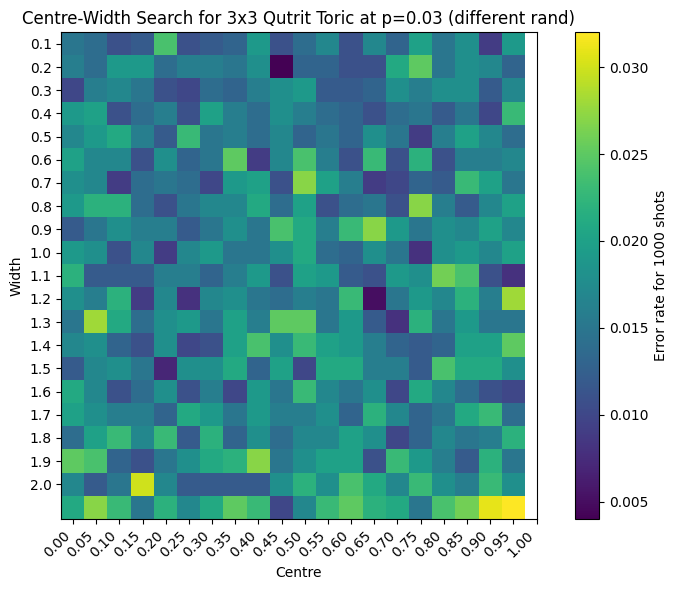

In [ ]:
results = np.array([[15., 14., 11., 12., 24., 11., 12., 13., 19., 11., 14., 17., 11., 17., 13., 20., 15., 18.,  9., 19.],
       [16., 14., 19., 19., 14., 16., 16., 15., 18.,  4., 13., 13., 11., 11., 21., 25., 15., 18., 17., 13.],
       [10., 16., 17., 15., 11., 10., 14., 13., 16., 18., 19., 12., 12., 13., 18., 16., 18., 18., 12., 17.],
       [19., 20., 11., 14., 16., 11., 20., 16., 14., 18., 16., 14., 13., 11., 14., 15., 12., 15., 10., 23.],
       [17., 19., 21., 16., 12., 23., 15., 16., 14., 17., 13., 15., 13., 18., 15.,  9., 16., 20., 17., 14.],
       [20., 17., 17., 11., 18., 13., 15., 25.,  9., 17., 24., 16., 11., 23., 11., 22., 11., 16., 16., 17.],
       [18., 17.,  9., 14., 15., 14., 10., 19., 20., 11., 27., 20., 16., 9., 10., 13., 12., 23., 20., 15.],
       [19., 22., 22., 14., 11., 15., 17., 17., 21., 14., 20., 11., 14., 15., 11., 27., 16., 12., 17., 20.],
       [12., 15., 18., 16., 16., 12., 15., 18., 15., 24., 21., 16., 23., 27., 19., 15., 18., 17., 20., 17.],
       [19., 18., 11., 17.,  9., 17., 19., 15., 15., 18., 21., 14., 13., 18., 15.,  8., 18., 19., 17., 20.],
       [22., 12., 12., 12., 16., 16., 13., 16., 19., 11., 20., 19., 12., 11., 19., 18., 26., 24., 11.,  8.],
       [18., 16., 22.,  9., 17.,  8., 17., 18., 15., 14., 16., 15., 23., 5., 15., 19., 17., 22., 16., 28.],
       [15., 28., 21., 14., 18., 19., 15., 20., 16., 25., 25., 15., 19., 12.,  8., 22., 15., 19., 15., 15.],
       [17., 18., 13., 11., 18., 10., 11., 20., 24., 18., 23., 20., 19., 16., 13., 12., 13., 20., 20., 25.],
       [12., 17., 18., 15.,  7., 18., 18., 21., 13., 20., 10., 21., 21., 16., 16., 12., 24., 21., 21., 18.],
       [21., 17., 11., 14., 18., 11., 16., 10., 19., 15., 23., 17., 15., 18., 10., 21., 17., 14., 11., 10.],
       [20., 18., 16., 16., 13., 21., 19., 15., 19., 16., 16., 18., 13., 22., 17., 13., 15., 21., 23., 14.],
       [14., 20., 23., 17., 23., 12., 22., 13., 18., 14., 17., 17., 20., 18., 10., 13., 17., 15., 16., 22.],
       [25., 24., 13., 11., 15., 18., 21., 22., 27., 15., 18., 20., 20., 11., 23., 19., 16., 12., 22., 15.],
       [17., 12., 15., 30., 17., 12., 12., 12., 12., 18., 22., 18., 24., 21., 17., 23., 18., 16., 23., 18.],
       [21., 27., 23., 15., 22., 17., 21., 25., 23., 10., 17., 23., 25., 22., 21., 15., 24., 26., 31., 32.]])

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 1000)

# Set ticks
ax.set_xticks(np.arange(len(centre)))
ax.set_yticks(np.arange(len(width)))

# Set tick labels
ax.set_xticklabels([f'{c:.2f}' for c in centre])
ax.set_yticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 1000 shots")

ax.set_title("Centre-Width Search for 3x3 Qutrit Toric at p=0.03 (different rand)")
ax.set_xlabel("Centre")
ax.set_ylabel("Width")

plt.tight_layout()
plt.show()


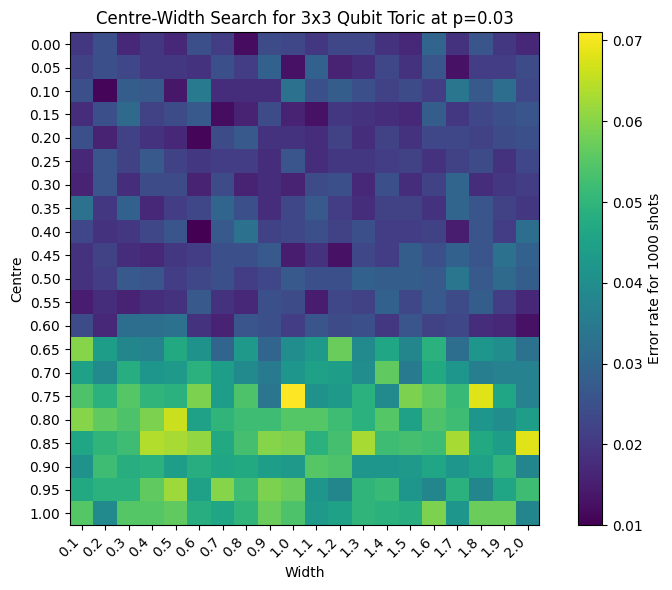

In [44]:
results = np.array([[20., 25., 17., 20., 17., 25., 21., 12., 24., 23., 20., 23., 23., 19., 17., 30., 19., 26., 20., 17.],
       [22., 25., 23., 20., 20., 19., 25., 21., 29., 13., 29., 16., 18., 23., 19., 26., 13., 21., 21., 24.],
       [25., 11., 28., 27., 14., 35., 18., 18., 18., 33., 25., 28., 25., 22., 24., 21., 34., 27., 32., 23.],
       [18., 25., 31., 22., 24., 27., 12., 16., 24., 16., 13., 20., 19., 18., 17., 28., 20., 23., 25., 26.],
       [25., 16., 22., 19., 17., 11., 24., 27., 19., 19., 18., 22., 18., 22., 19., 23., 23., 22., 24., 25.],
       [17., 26., 22., 27., 22., 20., 21., 21., 18., 26., 18., 20., 20., 21., 22., 19., 22., 24., 19., 23.],
       [16., 26., 18., 24., 24., 16., 24., 16., 18., 16., 24., 25., 17., 25., 18., 22., 30., 18., 20., 21.],
       [33., 20., 29., 17., 21., 23., 30., 25., 18., 23., 27., 21., 18., 22., 22., 19., 30., 26., 22., 20.],
       [23., 19., 20., 23., 26., 10., 27., 33., 22., 23., 25., 22., 25., 21., 21., 22., 15., 26., 21., 32.],
       [19., 22., 18., 17., 20., 21., 25., 25., 27., 15., 19., 13., 23., 21., 28., 25., 29., 26., 33., 29.],
       [19., 21., 27., 26., 21., 23., 25., 21., 23., 27., 25., 25., 29., 28., 28., 27., 34., 27., 31., 28.],
       [15., 18., 16., 18., 19., 27., 19., 17., 25., 24., 15., 23., 22., 29., 23., 27., 24., 28., 21., 17.],
       [24., 17., 32., 32., 33., 19., 16., 26., 25., 21., 26., 24., 25., 20., 26., 22., 23., 18., 17., 13.],
       [60., 44., 38., 37., 47., 41., 30., 43., 30., 40., 43., 57., 39., 46., 38., 49., 32., 42., 40., 33.],
       [45., 39., 48., 42., 43., 49., 44., 39., 35., 42., 45., 44., 40., 56., 35., 47., 42., 36., 37., 37.],
       [54., 49., 55., 50., 49., 59., 44., 54., 34., 71., 41., 43., 49., 39., 59., 56., 51., 68., 46., 37.],
       [60., 56., 54., 59., 66., 45., 50., 52., 52., 55., 55., 52., 49., 55., 45., 54., 52., 42., 40., 44.],
       [46., 50., 52., 64., 63., 61., 47., 53., 60., 59., 49., 53., 63., 52., 53., 52., 63., 47., 44., 68.],
       [41., 52., 48., 49., 44., 48., 46., 47., 44., 43., 55., 54., 42., 42., 43., 46., 42., 45., 50., 38.],
       [47., 49., 49., 56., 62., 45., 60., 52., 59., 57., 42., 38., 50., 51., 42., 38., 49., 38., 46., 52.],
       [55., 39., 55., 55., 56., 48., 46., 50., 57., 54., 43., 45., 50., 49., 48., 59., 42., 57., 57., 38.]])
centre = np.arange(0.0, 1.05, 0.05)
width = np.arange(0.1, 2.1, 0.1)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / 1000)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' for c in centre])
ax.set_xticklabels([f'{w:.1f}' for w in width])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label="Error rate for 1000 shots")

ax.set_title("Centre-Width Search for 3x3 Qubit Toric at p=0.03")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()
